In [1]:
import numpy as np
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from hierarchical_clustering import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import scipy.stats as stats
from scipy.special import gamma
from scipy.stats import multivariate_normal,f

In [2]:
import utils

m:  11
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
m:  17
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
m:  8
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
m:  16
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
m:  13
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
m:  3
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
leve

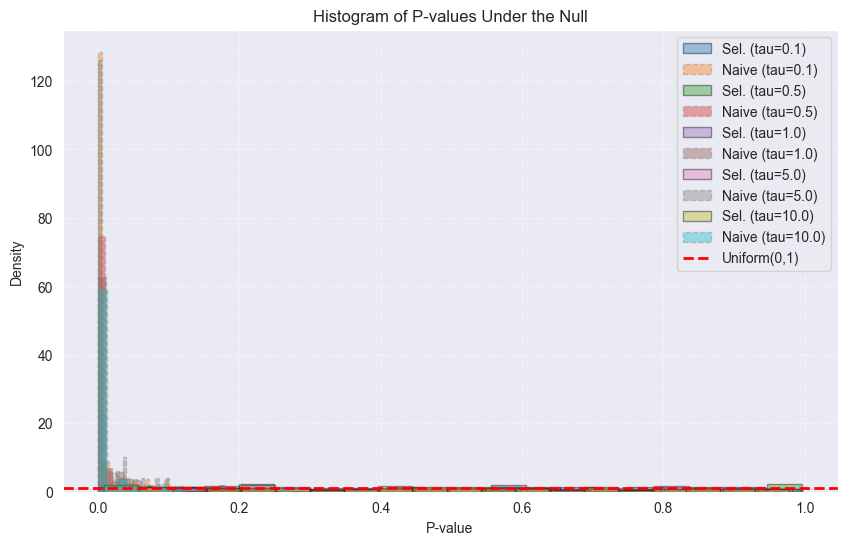

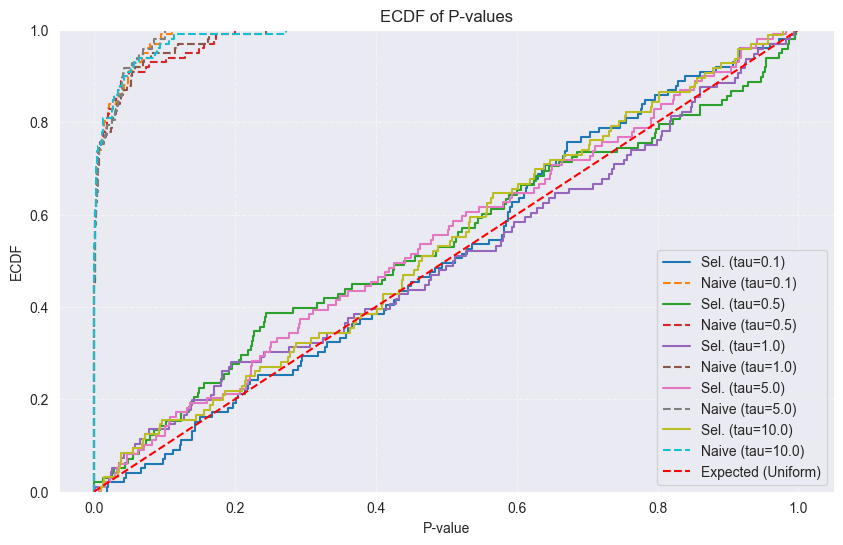

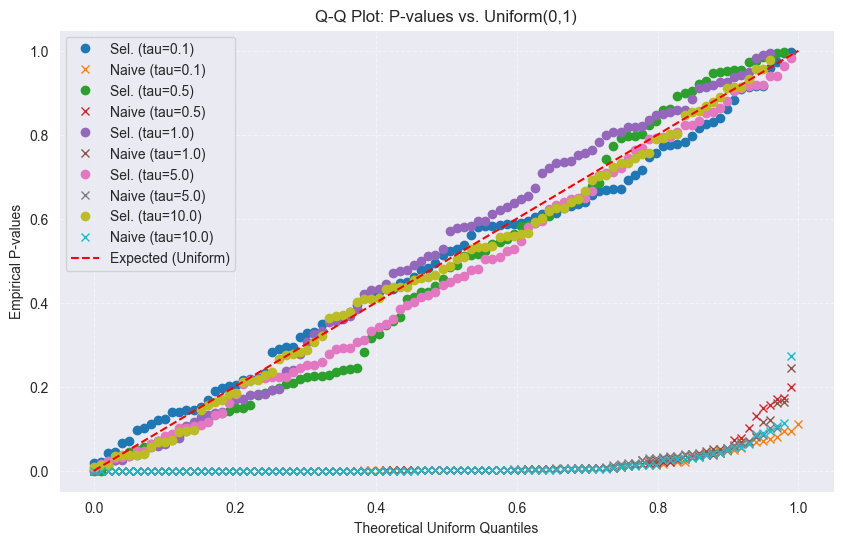

In [3]:
tau_list = np.array([0.1,0.5,1,5, 10])
utils.check_p_value_uniformity_multi_tau(n=20, p=2, sigma=1, K=3, tau_list=tau_list, layer=-1, linkage="average", num_trials=100)

In [6]:
def generate_null_data(n, p, mu, sigma):
    mu = np.array(mu)  # Ensure mu is an array
    cov = (sigma ** 2) * np.eye(p)  # Covariance matrix
    return np.random.multivariate_normal(mu, cov, size=n)
def fun_gen_X(n, p, ss, delta=0):
    #ss： the real unknown sigma
    n_each = round(n / 2)
    mu1 = np.ones(p)*delta
    cov = ss * np.eye(p)
    X1 = multivariate_normal.rvs(mean=mu1, cov=cov, size=n_each)
    X2 = np.random.normal(loc=0, scale=np.sqrt(ss), size=(n_each, p))

    X = np.vstack([X1, X2])

    return X

def compute_nu(node,n):
    # return the projection direction from the given node
    G_1= np.array(node.left.points)
    G_2 = np.array(node.right.points)
    n_G1 = len(G_1)
    n_G2 = len(G_2)

    nu = np.zeros(n)

    nu[G_1] += 1/n_G1
    nu[G_2] -= 1/n_G2
    return nu
def create_indicator_diagonal_matrix(index_list, n):
    diag = np.zeros(n)
    diag[index_list] = 1
    return np.diag(diag), diag

def naive_p_value(X, node,grid_width=50,ngrid=1000):
    from scipy.special import beta, gamma
    n = X.shape[0]
    p = X.shape[1]
    nu = compute_nu(node,n).reshape(-1,1)
    p_node_1 = node.left
    p_node_2 = node.right
    m = len(p_node_1.points)+len(p_node_2.points)
    if m <= 2:
        return np.nan
    P0 = nu@nu.T / np.linalg.norm(nu)**2
    I1, one1 = create_indicator_diagonal_matrix(p_node_1.points,n)
    I2, one2 = create_indicator_diagonal_matrix(p_node_2.points,n)
    one1 = one1.reshape(-1,1)
    one2 = one2.reshape(-1,1)
    P1 = (I1 - one1@one1.T / len(p_node_1.points)) + (I2 - one2@one2.T / len(p_node_2.points))
    P2 = np.eye(n) - P0 - P1
    
    S = np.linalg.norm(P0 @ X, 'fro')**2 + np.linalg.norm(P1 @ X, 'fro')**2
    R0 = P0 @ X / np.linalg.norm(P0 @X, 'fro')
    R1 = P1 @ X / np.linalg.norm(P1 @ X, 'fro')
    
    observed_target = (m - 2) * np.linalg.norm(P0 @ X, 'fro') ** 2 / np.linalg.norm(P1 @ X,'fro') ** 2
    print("Are they close?", np.allclose(X, (np.sqrt(observed_target/(m-2+observed_target)) * R0 + np.sqrt((m-2)/(m-2+observed_target)) * R1) *np.sqrt(S) + P2 @X))
    
    p_value = 1 - f.cdf(observed_target, dfn = p,dfd = (m-2)*p)

    
    return p_value




def check_p_value_uniformity(n,p, sigma, K, tau,layer, linkage = "average", num_trials=1000):
    p_values = []
    p_values_n = []
    observed = []
    mu = np.zeros(p)  

    while len(p_values_n) < num_trials:
        X = generate_null_data(n,p,mu,sigma)
        #X = fun_gen_X(n,p,sigma)
        #X = np.random.standard_t(5, size=(n, p))
        # Fit agglomerative clustering
        model = AgglomerativeClustering(X, tau=tau, n_clusters=K,linkage=linkage)
        model.fit()

        winning_nodes = list(model.existing_clusters_log.keys())
        key = winning_nodes[layer]
        node = key[0].parent
        p_value, obs,sel_corrected = model.merge_inference_F(node,grid_width= 50, ncoarse=100,ngrid = 2000)
        p_value_n = naive_p_value(X,node)
        if not np.isnan(p_value_n):
            p_values.append(p_value)
            p_values_n.append(p_value_n)
            #observed.append(obs)
        #print(sel_corrected)
    p_values = np.array(p_values)
    p_values_n = np.array(p_values_n)
    #print(p_values_n)
    #print(p_values)

    # Histogram for both p-values
    plt.figure(figsize=(8, 5))
    plt.hist(p_values, bins=20, density=True, alpha=0.5, color="blue", edgecolor="black", label="Selection-based p-value")
    plt.hist(p_values_n, bins=20, density=True, alpha=0.5, color="orange", edgecolor="black", label="Naive p-value")
    plt.axhline(1, color='red', linestyle='dashed', linewidth=2, label="Uniform(0,1)")
    plt.xlabel("P-value")
    plt.ylabel("Density")
    plt.title("Histogram of P-values Under the Null Hypothesis")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()
    
    plt.figure(figsize=(8, 5))
    sns.ecdfplot(p_values, color="blue", label="Selection-based p-values")
    sns.ecdfplot(p_values_n, color="orange", label="Naive p-values")
    plt.plot([0, 1], [0, 1], linestyle="--", color="red", label="Expected (Uniform)")
    plt.xlabel("P-value")
    plt.ylabel("ECDF")
    plt.title("Empirical CDF of P-values")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

    # Q-Q Plot for both p-values
    plt.figure(figsize=(8, 5))
    sorted_p_values = np.sort(p_values)
    sorted_p_values_n = np.sort(p_values_n)
    theoretical_quantiles = np.linspace(0, 1, num_trials)

    plt.plot(theoretical_quantiles, sorted_p_values, marker='o', linestyle='', color="blue", label="Selection-based p-values")
    plt.plot(theoretical_quantiles, sorted_p_values_n, marker='o', linestyle='', color="orange", label="Naive p-values")
    plt.plot([0, 1], [0, 1], linestyle="--", color="red", label="Expected (Uniform)")
    plt.xlabel("Theoretical Uniform Quantiles")
    plt.ylabel("Empirical P-values")
    plt.title("Q-Q Plot: P-values vs. Uniform(0,1)")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

size:  12
Are they close? True
m:  12
level:  20
level:  19
level:  18
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
Are they close? True
size:  9
Are they close? True
m:  9
level:  20
level:  19
level:  18
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
Are they close? True
size:  3
Are they close? True
m:  3
level:  20
level:  19
level:  18
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
Are they close? True
size:  5
Are they close? True
m:  5
level:  20
level:  19
level:  18
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level: 

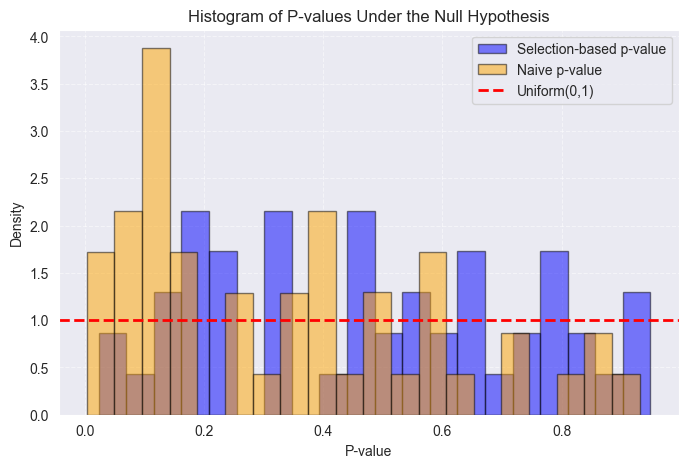

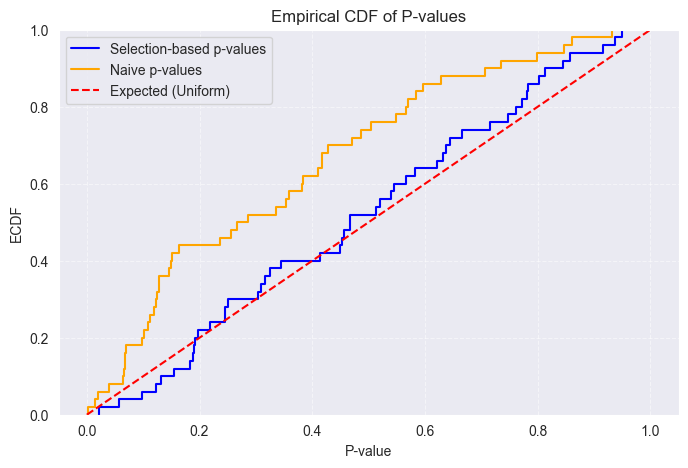

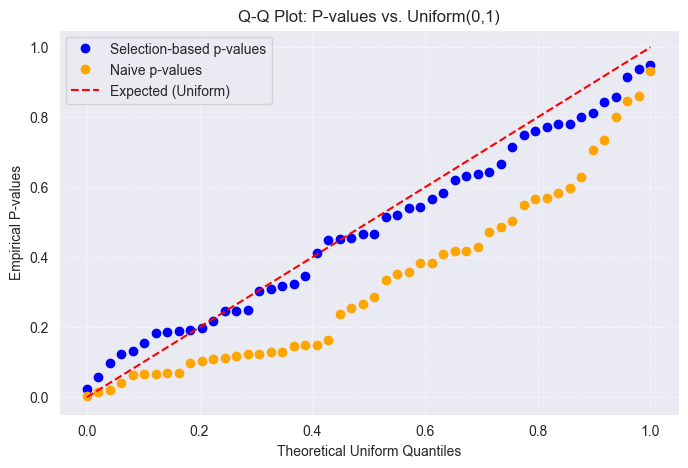

In [7]:
check_p_value_uniformity(30,2,1,10,1,-1,50)

In [24]:
def generate_null_data(n, p, mu, sigma):
    mu = np.array(mu)  # Ensure mu is an array
    cov = (sigma ** 2) * np.eye(p)  # Covariance matrix
    return np.random.multivariate_normal(mu, cov, size=n)
def fun_gen_X(n, p, ss, delta=0):
    #ss： the real unknown sigma
    n_each = round(n / 2)
    mu1 = np.ones(p)*delta
    cov = ss * np.eye(p)
    X1 = multivariate_normal.rvs(mean=mu1, cov=cov, size=n_each)
    X2 = np.random.normal(loc=0, scale=np.sqrt(ss), size=(n_each, p))

    X = np.vstack([X1, X2])

    return X

def compute_nu(node,n):
    # return the projection direction from the given node
    G_1= np.array(node.left.points)
    G_2 = np.array(node.right.points)
    n_G1 = len(G_1)
    n_G2 = len(G_2)

    nu = np.zeros(n)

    nu[G_1] += 1/n_G1
    nu[G_2] -= 1/n_G2
    return nu
def create_indicator_diagonal_matrix(index_list, n):
    diag = np.zeros(n)
    diag[index_list] = 1
    return np.diag(diag), diag
def naive_p_value(X, node,grid_width=50,ngrid=1000):
    from scipy.special import beta, gamma
    n = X.shape[0]
    p = X.shape[1]
    nu = compute_nu(node,n).reshape(-1,1)
    p_node_1 = node.left
    p_node_2 = node.right
    m = len(p_node_1.points)+len(p_node_2.points)
    if m <= 2:
        return np.nan
    P0 = nu@nu.T / np.linalg.norm(nu)**2
    I1, one1 = create_indicator_diagonal_matrix(p_node_1.points,n)
    I2, one2 = create_indicator_diagonal_matrix(p_node_2.points,n)
    one1 = one1.reshape(-1,1)
    one2 = one2.reshape(-1,1)
    P1 = (I1 - one1@one1.T / len(p_node_1.points)) + (I2 - one2@one2.T / len(p_node_2.points))
    P2 = np.eye(n) - P0 - P1

    S = np.linalg.norm(P0 @ X, 'fro')**2 + np.linalg.norm(P1 @ X, 'fro')**2
    R0 = P0 @ X / np.linalg.norm(P0 @X, 'fro')
    R1 = P1 @ X / np.linalg.norm(P1 @ X, 'fro')
    
    observed_target = (m - 2) * np.linalg.norm(P0 @ X, 'fro') ** 2 / np.linalg.norm(P1 @ X,'fro') ** 2
    print("Are they close?", np.allclose(X, (np.sqrt(observed_target/(m-2+observed_target)) * R0 + np.sqrt((m-2)/(m-2+observed_target)) * R1) *np.sqrt(S) + P2 @X))
    
    df1 = p
    df2 = p * (m-2)
    #p_value = 1 - f.cdf(observed_target, dfn = p,dfd = (m-2)*p)
    
    stat_grid = np.linspace(0.0000001, grid_width,
                                    num=ngrid)
    pdf = np.zeros((ngrid,)) 
    for g in range(ngrid):
       #pdf[g] = np.sqrt(((df1*stat_grid[g])**df1 * df2**df2)/((df1*stat_grid[g] + df2)**(df1 + df2)))/(stat_grid[g] * beta(df1/2,df2/2))
        pdf[g] = gamma((df1+df2)/2)/(gamma(df1/2) * gamma(df2/2)) * (df1/df2)**(df1/2) * stat_grid[g]**((df1-2)/2)/((1+(df1/df2)*stat_grid[g])**((df1+df2)/2))
        
    pdf = pdf/ np.max(pdf)
    sum = 0
    num = 0
    for g in range(ngrid):
        sum += pdf[g]
        if stat_grid[g] >= observed_target:
            num += pdf[g]
    p_value = num/sum
    
    

    return p_value

def check_p_value_uniformity(n,p, sigma, K, tau,layer, num_trials=1000):
    p_values_F = []
    p_values_chi = []
    observed = []
    mu = np.zeros(p)  

    while len(p_values_F) < num_trials:
        #X = generate_null_data(n,p,mu,sigma)
        X = fun_gen_X(n,p,sigma)
        #X = np.random.standard_t(5, size=(n, p))
        # Fit agglomerative clustering
        model = AgglomerativeClustering(X, tau=tau, n_clusters=K,linkage="average")
        model.fit()

        winning_nodes = list(model.existing_clusters_log.keys())
        key = winning_nodes[layer]
        node = key[0].parent
        p_value_F, obs,sel_corrected = model.merge_inference_F(node,grid_width= 50, ncoarse=100,ngrid = 2000)
        p_value_chi, obs_c, sel_c = model.merge_inference_chi(node,grid_width= 50, ncoarse=100,ngrid = 2000,sd=1)
        if not np.isnan(p_value_F):
            p_values_F.append(p_value_F)
            p_values_chi.append(p_value_chi)
            #observed.append(obs)
        #print(sel_corrected)
    p_values_F = np.array(p_values_F)
    p_values_chi = np.array(p_values_chi)
    '''
    plt.figure(figsize=(8, 5))
    plt.hist(observed, bins=20, density=True, alpha=0.5, color="blue", edgecolor="black", label="observed target")
    plt.xlabel("P-value")
    plt.ylabel("Density")
    plt.title("Histogram of observed target Under the Null Hypothesis")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()
    '''
    
    
    # Histogram for both p-values
    plt.figure(figsize=(8, 5))
    plt.hist(p_values_F, bins=20, density=True, alpha=0.5, color="blue", edgecolor="black", label="p-value (F distribution)")
    plt.hist(p_values_chi, bins=20, density=True, alpha=0.5, color="orange", edgecolor="black", label="p-value (chi distribution)")
    plt.axhline(1, color='red', linestyle='dashed', linewidth=2, label="Uniform(0,1)")
    plt.xlabel("P-value")
    plt.ylabel("Density")
    plt.title("Histogram of P-values Under the Null Hypothesis")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()
    
    plt.figure(figsize=(8, 5))
    sns.ecdfplot(p_values_F, color="blue", label="p-value (F distribution)")
    sns.ecdfplot(p_values_chi, color="orange", label="p-value (chi distribution)")
    plt.plot([0, 1], [0, 1], linestyle="--", color="red", label="Expected (Uniform)")
    plt.xlabel("P-value")
    plt.ylabel("ECDF")
    plt.title("Empirical CDF of P-values")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

    # Q-Q Plot for both p-values
    plt.figure(figsize=(8, 5))
    sorted_p_values = np.sort(p_values_F)
    sorted_p_values_n = np.sort(p_values_chi)
    theoretical_quantiles = np.linspace(0, 1, num_trials)

    plt.plot(theoretical_quantiles, sorted_p_values, marker='o', linestyle='', color="blue", label="p-value (F distribution)")
    plt.plot(theoretical_quantiles, sorted_p_values_n, marker='o', linestyle='', color="orange", label="p-value (chi distribution)")
    plt.plot([0, 1], [0, 1], linestyle="--", color="red", label="Expected (Uniform)")
    plt.xlabel("Theoretical Uniform Quantiles")
    plt.ylabel("Empirical P-values")
    plt.title("Q-Q Plot: P-values vs. Uniform(0,1)")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

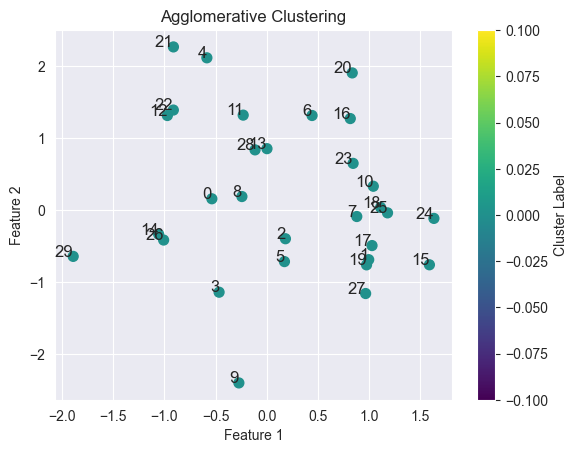

In [16]:
X =  fun_gen_X(30,2,1)

# Fit agglomerative clustering
model = AgglomerativeClustering(X, tau=1, n_clusters=1,linkage="complete")
model.fit()
# Create an array to hold the assigned cluster labels
cluster_labels = np.zeros(X.shape[0], dtype=int)

# Assign cluster labels from the final cluster nodes
for idx, node in enumerate(model.K_clusters):
    for point_index in node.points:
        cluster_labels[point_index] = idx
    # Visualize the clusters
plt.scatter(X[:, 0], X[:, 1], s=50, c=cluster_labels, cmap='viridis', label='Data Points')
plt.title('Agglomerative Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Cluster Label')
for i in range(len(X)):
    plt.annotate(str(i), (X[i, 0], X[i, 1]), fontsize=12, ha='right')

plt.show()

In [22]:
winning_nodes = list(model.existing_clusters_log.keys())
key = winning_nodes[-1]
node = key[0].parent
p_node_1 = node.left
p_node_2 = node.right

In [23]:
nu = compute_nu(node,30).reshape(-1,1)
P0 = nu@nu.T / np.linalg.norm(nu)**2
I1, one1 = create_indicator_diagonal_matrix(p_node_1.points,30)
I2, one2 = create_indicator_diagonal_matrix(p_node_2.points,30)

In [25]:
one1@one1.T

np.float64(8.0)

In [20]:
v= np.ones(5).reshape(-1,1)
v@v.T

array([[1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1.]])

size:  30
Are they close? True
m:  30
level:  29
level:  28
level:  27
level:  26
level:  25
level:  24
level:  23
level:  22
level:  21
level:  20
level:  19
level:  18
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  29
level:  28
level:  27
level:  26
level:  25
level:  24
level:  23
level:  22
level:  21
level:  20
level:  19
level:  18
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
size:  30
Are they close? True
m:  30
level:  29
level:  28
level:  27
level:  26
level:  25
level:  24
level:  23
level:  22
level:  21
level:  20
level:  19
level:  18
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
leve

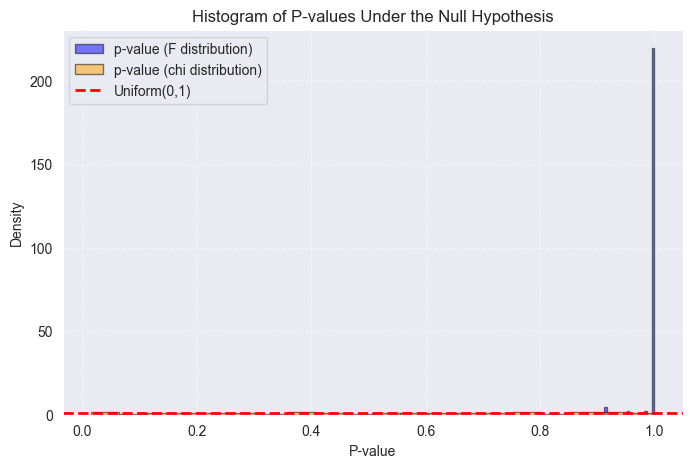

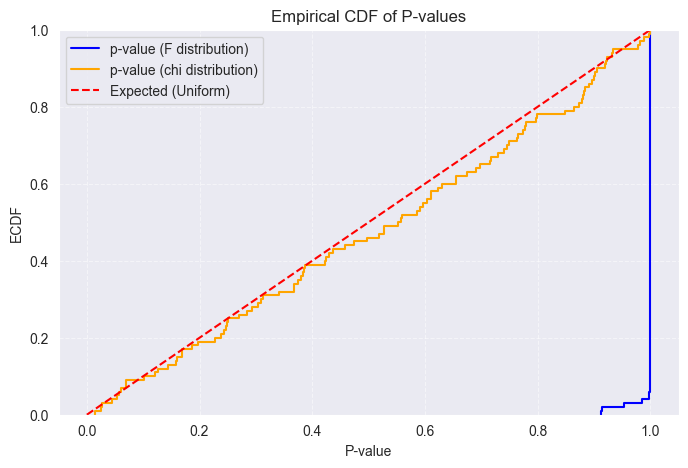

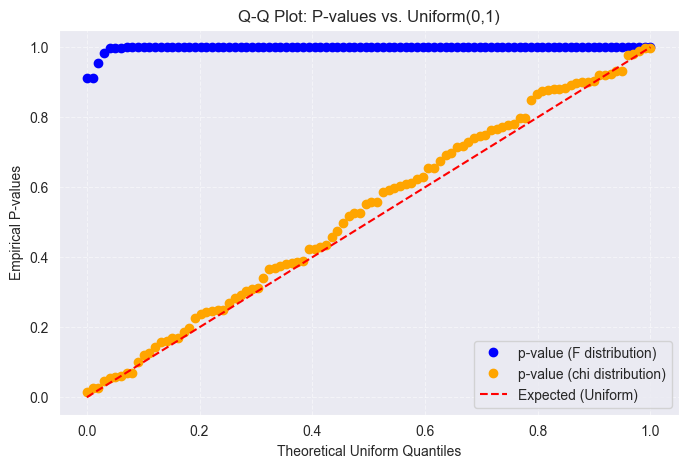

In [12]:
check_p_value_uniformity(30,2,1,1,3,-1,100)

Are they close? True
Are they close? True
Are they close? True
Are they close? True
Are they close? True
Are they close? True
Are they close? True
Are they close? True
Are they close? True
Are they close? True
Are they close? True
Are they close? True
Are they close? True
Are they close? True
Are they close? True
Are they close? True
Are they close? True
Are they close? True
Are they close? True
Are they close? True
Are they close? True
Are they close? True
Are they close? True
Are they close? True
Are they close? True
Are they close? True
Are they close? True
Are they close? True
Are they close? True
Are they close? True
Are they close? True
Are they close? True
Are they close? True
Are they close? True
Are they close? True
Are they close? True
Are they close? True
Are they close? True
Are they close? True
Are they close? True
Are they close? True
Are they close? True
Are they close? True
Are they close? True
Are they close? True
Are they close? True
Are they close? True
Are they clos

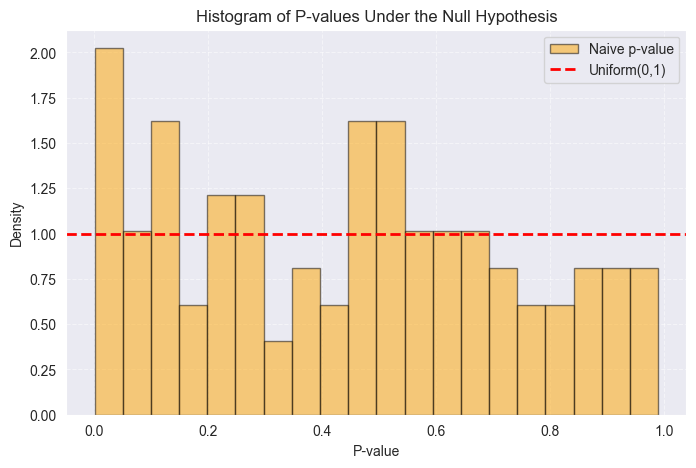

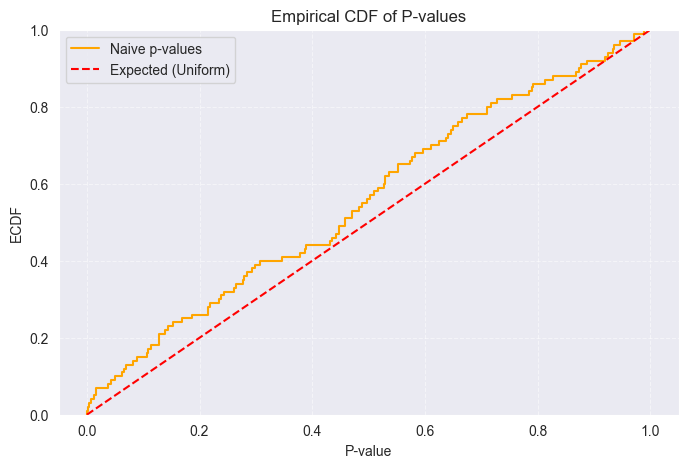

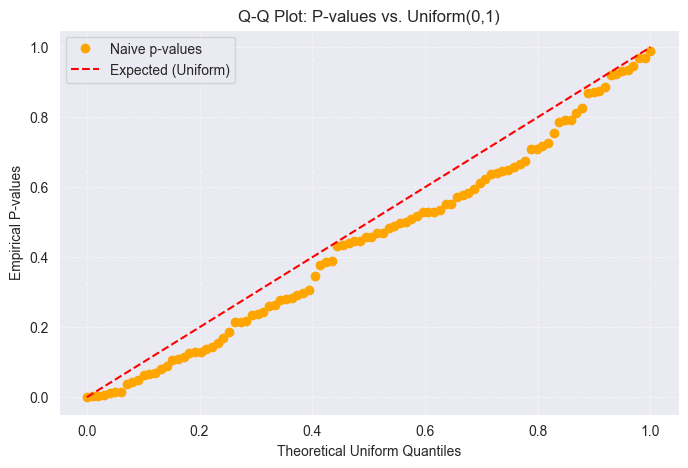

In [32]:
check_p_value_uniformity(30,2,1,1,100,-1,100)

size:  27
Are they close? True
m:  27
level:  28
level:  27
level:  26
level:  25
level:  24
level:  23
level:  22
level:  21
level:  20
level:  19
level:  18
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
Are they close? True
[-125.48609199 -125.33406843 -125.18616766 ... -120.52502488 -120.52509509
 -120.52516526]
size:  28
Are they close? True
m:  28
level:  28
level:  27
level:  26
level:  25
level:  24
level:  23
level:  22
level:  21
level:  20
level:  19
level:  18
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
Are they close? True
[-125.83964256 -125.72806092 -125.61932558 ... -120.43454239 -120.43440221
 -120.43426216]
size:  17
Are they close? True
m:  17
level:  28
level:  27
level:  26
level:  25
level:  24
level:  2

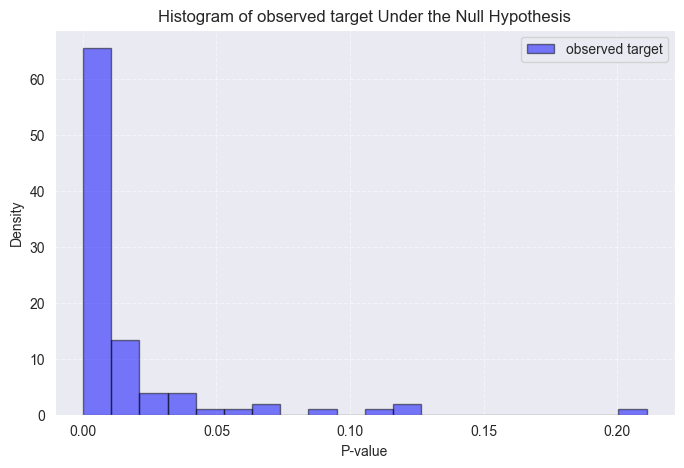

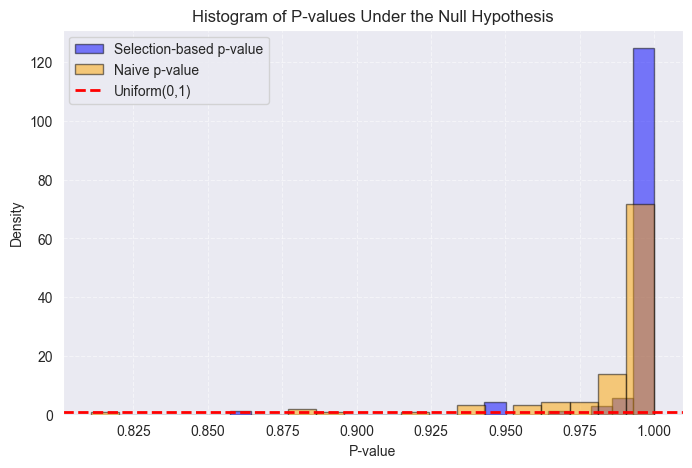

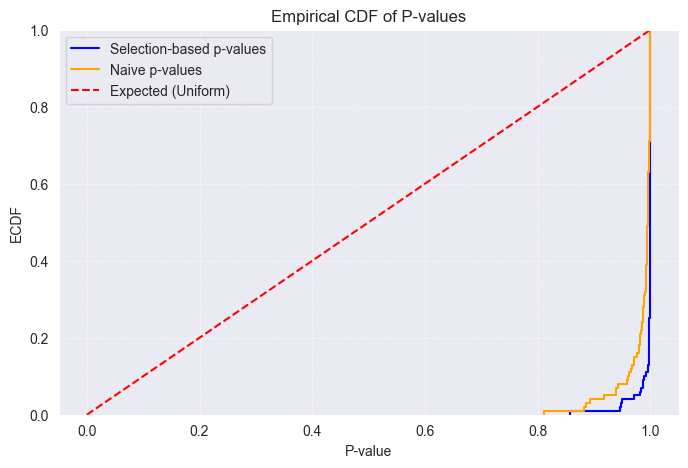

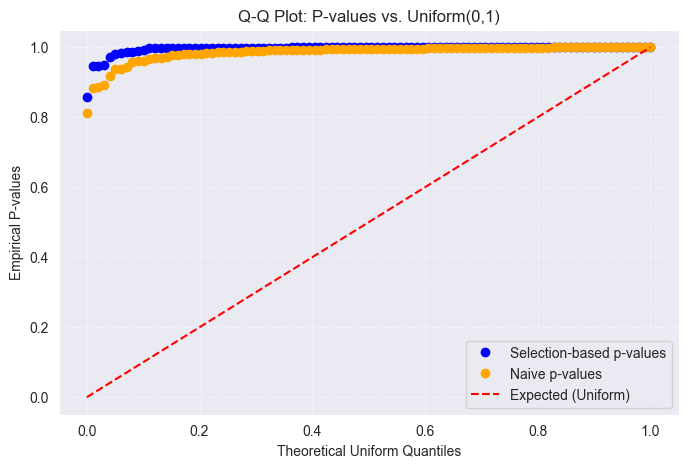

In [4]:
check_p_value_uniformity(30,2,1,2,10,-1,100)

size:  27
Are they close? True
m:  27
level:  28
level:  27
level:  26
level:  25
level:  24
level:  23
level:  22
level:  21
level:  20
level:  19
level:  18
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
Are they close? True
[-121.02431703 -120.38997941 -119.78648618 ... -142.76647828 -142.77019723
 -142.77391369]
size:  29
Are they close? True
m:  29
level:  28
level:  27
level:  26
level:  25
level:  24
level:  23
level:  22
level:  21
level:  20
level:  19
level:  18
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
Are they close? True
[-120.30761969 -118.92995459 -117.60256965 ... -115.56704662 -115.56891739
 -115.57078686]
size:  27
Are they close? True
m:  27
level:  28
level:  27
level:  26
level:  25
level:  24
level:  2

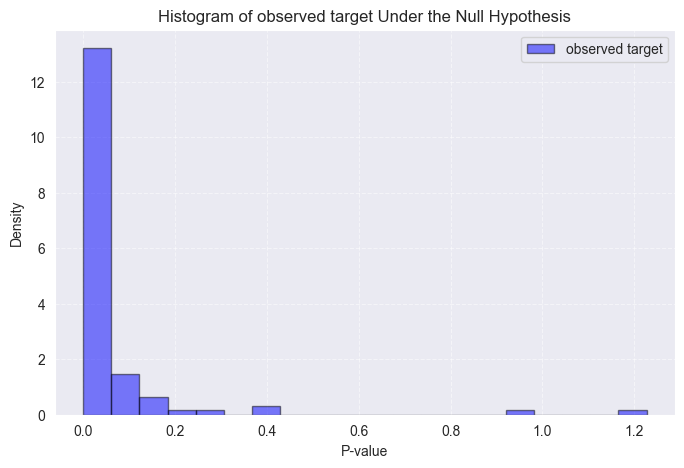

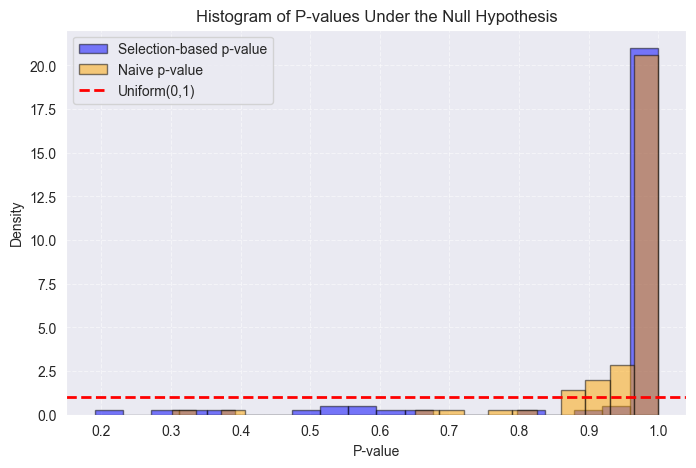

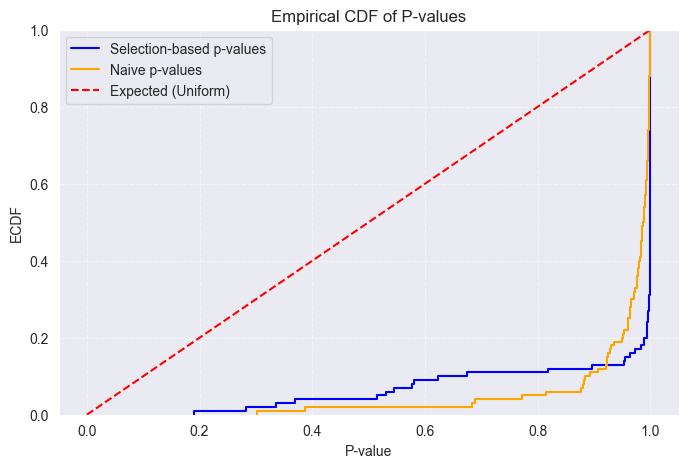

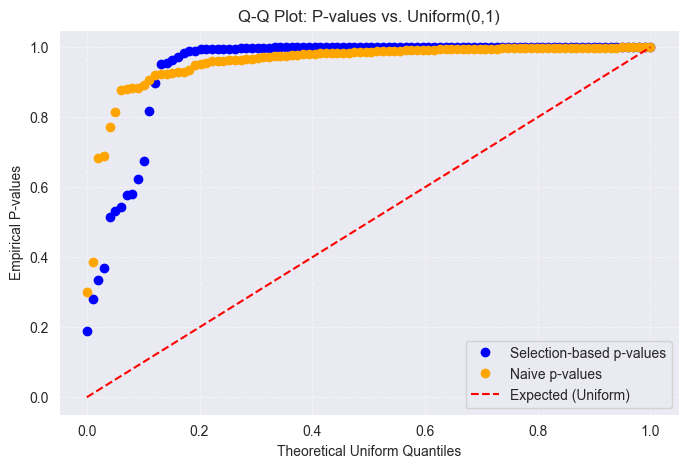

In [5]:
check_p_value_uniformity(30,2,1,2,1,-1,100)

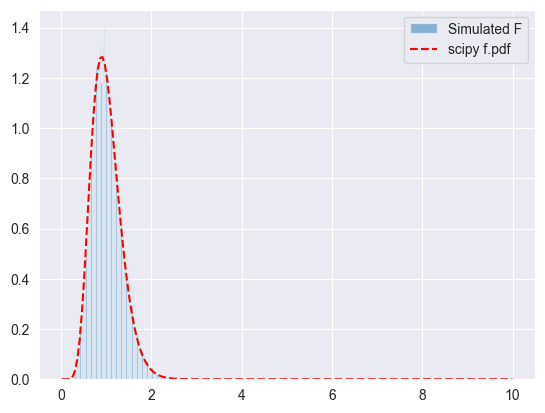

In [12]:
from scipy.stats import f
import matplotlib.pyplot as plt
p=20
m=20
# Simulate under null
sim_stat = (np.random.chisquare(p, 10000) / p) / (np.random.chisquare((m-2)*p, 10000) / ((m-2)*p))

# Compare histogram with f.pdf
x = np.linspace(0.01, 10, 200)
plt.hist(sim_stat, bins=100, density=True, alpha=0.5, label='Simulated F')
plt.plot(x, f.pdf(x, p, (m-2)*p), 'r--', label='scipy f.pdf')
plt.legend()

14
1.528304645446974
142.50032388570358
0.12869904604619373
Are they close? True
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
4
0.6077269631477977
7737.24336530392
0.00015709133975881504
Are they close? True
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
16
7.114982476606131
7748.132690278167
0.012855969128854675
Are they close? True
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
8
0.852323325927692
836.0994900883874
0.006116425157759081
Are they close? True
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
leve

/Users/judydw/Documents/GitHub/SI_HierarchicalClustering/hierarchical_clustering.py:513: RuntimeWarning: invalid value encountered in scalar divide
  print("Are they close?", np.allclose(self.X, (np.sqrt(observed_target/(m-2+observed_target)) * R0 + np.sqrt((m-2)/(m-2+observed_target)) * R1) *np.sqrt(S) + P2 @ self.X))


level:  4
level:  3
level:  2
level:  1
3
6.847127038157289
3044.468514451808
0.002249038545038195
Are they close? True
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
5
10.002149922717782
3943.248436114978
0.007609576280645587
Are they close? True
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
9
4.079690183326379
5645.980141188137
0.00505808213439358
Are they close? True
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
9
2.405023999492738
1609.2701410894826
0.010461368521416601
Are they close? True
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level: 

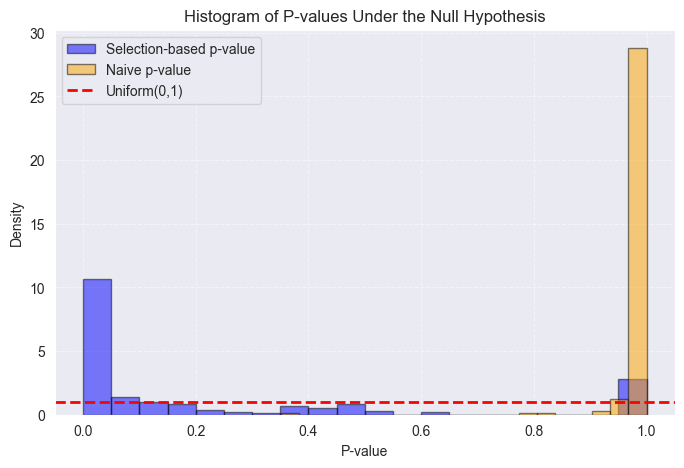

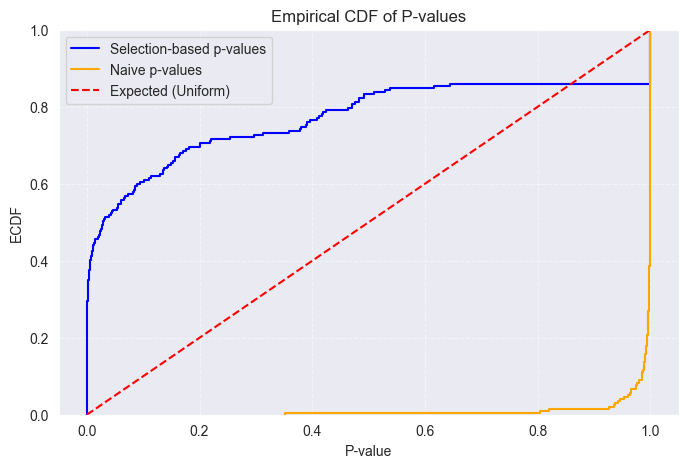

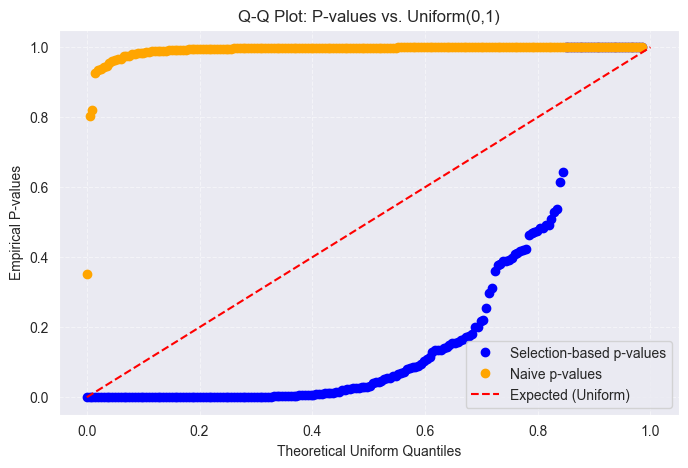

In [12]:
check_p_value_uniformity(20,3,1,3,1,-1,200)

11
3.379116482051585
6117.097736830152
0.0049716466283279675
Are they close? True
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
12
6.6611666450512645
12506.163054321436
0.0053263072103873895
Are they close? True
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
12
7.882554081218053
15511.847856007482
0.005081634473461696
Are they close? True
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
12
7.078260186649479
12273.229724327473
0.005767235149700859
Are they close? True
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  

/Users/judydw/Documents/GitHub/SI_HierarchicalClustering/hierarchical_clustering.py:513: RuntimeWarning: invalid value encountered in scalar divide
  print("Are they close?", np.allclose(self.X, (np.sqrt(observed_target/(m-2+observed_target)) * R0 + np.sqrt((m-2)/(m-2+observed_target)) * R1) *np.sqrt(S) + P2 @ self.X))


level:  4
level:  3
level:  2
level:  1
7
9.622910827889784
15746.423190835772
0.0030555862468786567
Are they close? True
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
11
16.75468603534738
5574.416288251007
0.027050755903527613
Are they close? True
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
10
15.559794870367414
5737.766706195759
0.02169456608065382
Are they close? True
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
13
3.567543556757477
3271.2335815888723
0.011996385505822401
Are they close? True
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
le

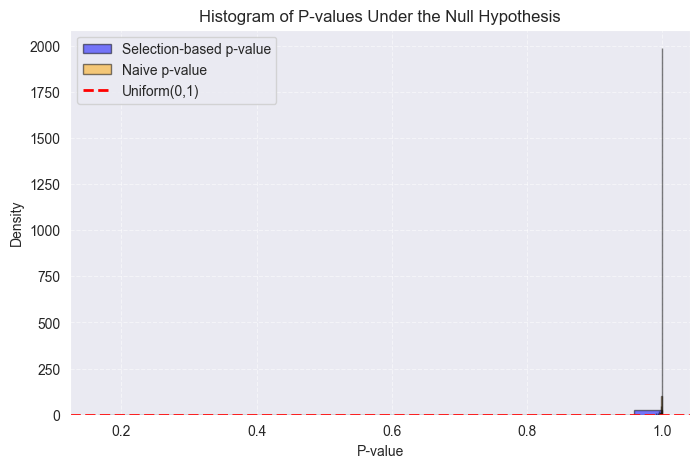

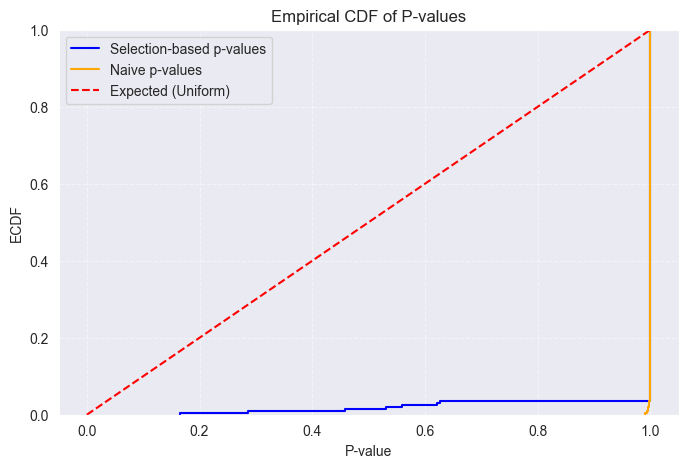

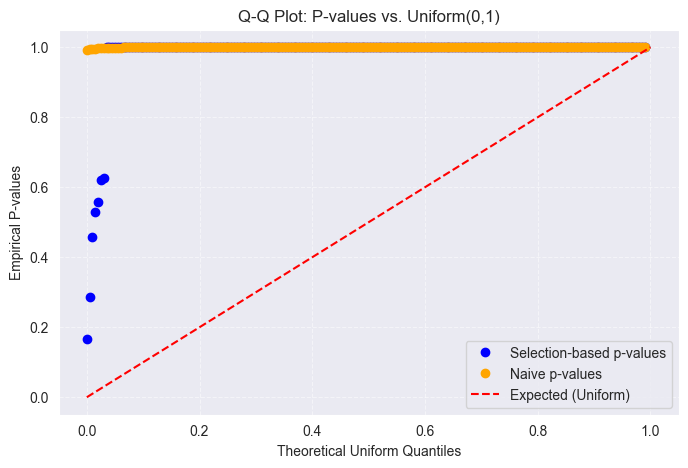

In [4]:
check_p_value_uniformity(20,5,1,3,1,-1,200)

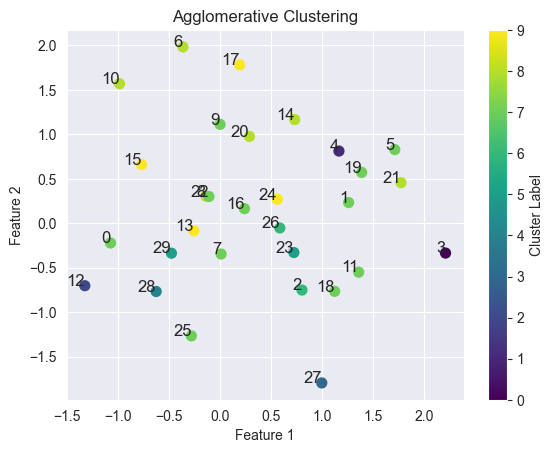

In [13]:
#X = np.random.uniform(-1, 1, size=(4, 2))
#X, y = make_blobs(n_samples=20, centers=19, cluster_std=1,random_state=42)
n=30
p=20
sigma=1
mu = np.zeros(p)  
X = generate_null_data(n,p,mu,sigma)
# Fit agglomerative clustering
model = AgglomerativeClustering(X, tau=1, n_clusters=10,linkage="single")
model.fit()
# Create an array to hold the assigned cluster labels
cluster_labels = np.zeros(X.shape[0], dtype=int)

# Assign cluster labels from the final cluster nodes
for idx, node in enumerate(model.K_clusters):
    for point_index in node.points:
        cluster_labels[point_index] = idx
    # Visualize the clusters
plt.scatter(X[:, 0], X[:, 1], s=50, c=cluster_labels, cmap='viridis', label='Data Points')
plt.title('Agglomerative Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Cluster Label')
for i in range(len(X)):
    plt.annotate(str(i), (X[i, 0], X[i, 1]), fontsize=12, ha='right')

plt.show()

In [15]:
winning_nodes = list(model.existing_clusters_log.keys())
key = winning_nodes[-1]
node = key[0].parent
p_value, obs,sel_corrected = model.merge_inference(node,grid_width= 3, ncoarse=50,ngrid = 2000)

4
8.595755082993874
137191.34683374563
0.0001253104555261868
Are they close? True
level:  20
level:  19
level:  18
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1


In [16]:
sel_corrected

array([ -95.19754539,  -96.99148322,  -98.76612318, ..., -408.0780753 ,
       -408.11091941, -408.14373975])

In [18]:
n=30
K=10
np.linspace(0.00001, 20, num=100)
winning_nodes = list(model.existing_clusters_log.keys())
key = winning_nodes[n - K-1]
node = key[0].parent
model.merge_inference(node)

Are they close? True
level:  20
level:  19
level:  18
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1


(np.float64(0.9959554418998877),
 np.float64(0.054442539122172375),
 array([ -99.81941144,  -99.82169968,  -99.82398593, ..., -101.61713972,
        -101.61713326, -101.6171268 ]))

In [16]:
winning_nodes

[(ClusterNode(points=[16]), ClusterNode(points=[24])),
 (ClusterNode(points=[13]), ClusterNode(points=[26])),
 (ClusterNode(points=[20]), ClusterNode(points=[23])),
 (ClusterNode(points=[22]), ClusterNode(points=[25])),
 (ClusterNode(points=[15]), ClusterNode(points=[20, 23])),
 (ClusterNode(points=[21]), ClusterNode(points=[29])),
 (ClusterNode(points=[12]), ClusterNode(points=[17])),
 (ClusterNode(points=[2]), ClusterNode(points=[19])),
 (ClusterNode(points=[0]), ClusterNode(points=[5])),
 (ClusterNode(points=[2, 19]), ClusterNode(points=[0, 5])),
 (ClusterNode(points=[21, 29]), ClusterNode(points=[12, 17])),
 (ClusterNode(points=[13, 26]), ClusterNode(points=[2, 19, 0, 5])),
 (ClusterNode(points=[6]), ClusterNode(points=[21, 29, 12, 17])),
 (ClusterNode(points=[4]), ClusterNode(points=[15, 20, 23])),
 (ClusterNode(points=[27]), ClusterNode(points=[4, 15, 20, 23])),
 (ClusterNode(points=[1]), ClusterNode(points=[13, 26, 2, 19, 0, 5])),
 (ClusterNode(points=[3]), ClusterNode(points=[1

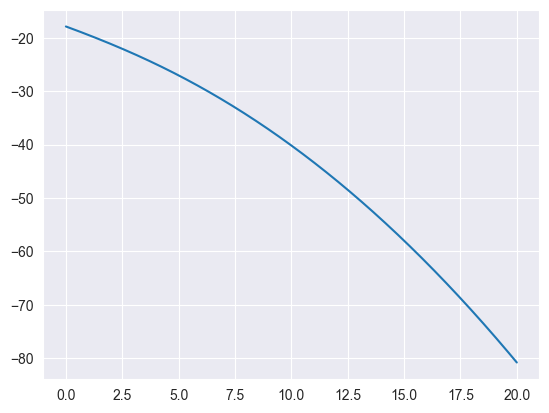

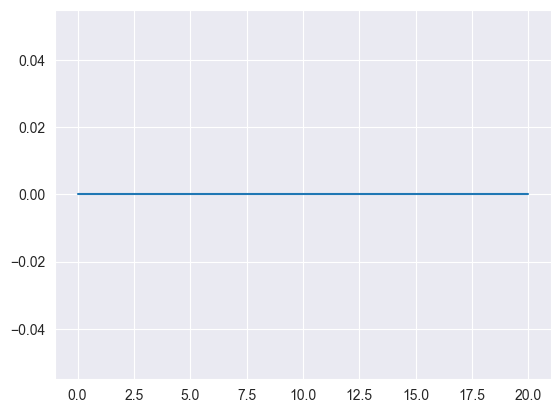

In [12]:
ref_norm_cor = (sel_corrected)
#x = np.linspace(0, 1.5*np.abs(obs_tar), 10000)
x = np.linspace(grid_lower, grid_upper,num=1000)
ref_norm = sel_prob
#x = np.linspace(0, 1.5*np.abs(obs_tar), 10000)
y = np.linspace(0.00001,20,num=1000)
plt.plot(y, ref_norm)
plt.show()
plt.plot(x, ref_norm_cor)
plt.show()

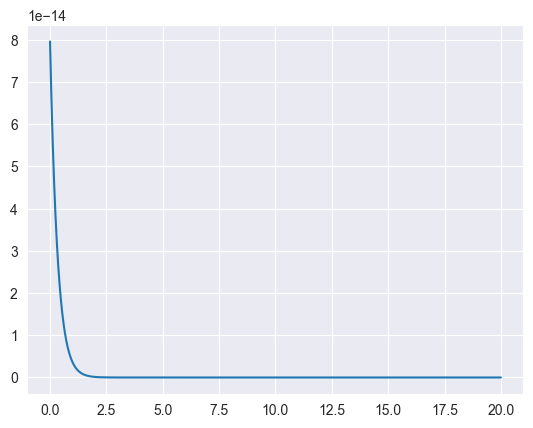

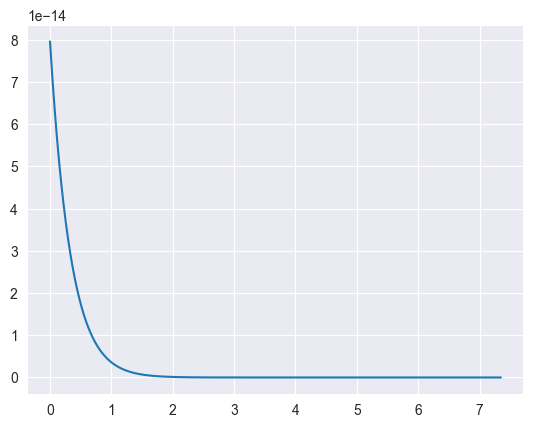

In [6]:
ref_norm_cor = np.exp(sel_corrected)
#x = np.linspace(0, 1.5*np.abs(obs_tar), 10000)
x = np.linspace(grid_lower, grid_upper,num=1000)
ref_norm = np.exp(sel_prob)
#x = np.linspace(0, 1.5*np.abs(obs_tar), 10000)
y = np.linspace(0.00001, 20,num=1000)
plt.plot(y, ref_norm)
plt.show()
plt.plot(x, ref_norm_cor)
plt.show()

In [44]:
sel_prob

array([-333.57815006, -333.57992968, -333.5808916 , -333.58103582,
       -333.58036233, -333.57887114, -333.57656225, -333.57343565,
       -333.56949135, -333.56472934, -333.55914963, -333.55275222,
       -333.5455371 , -333.53750428, -333.52865376, -333.51898553,
       -333.5084996 , -333.49719596, -333.48507462, -333.47213558,
       -333.45837883, -333.44380438, -333.42841223, -333.41220237,
       -333.39517481, -333.37732954, -333.35866657, -333.3391859 ,
       -333.31888753, -333.29777144, -333.27583766, -333.25308617,
       -333.22951698, -333.20513009, -333.17992549, -333.15390319,
       -333.12706318, -333.09940547, -333.07093006, -333.04163694,
       -333.01152612, -332.98059759, -332.94885136, -332.91628743,
       -332.8829058 , -332.84870646, -332.81368941, -332.77785467,
       -332.74120221, -332.70373206, -332.6654442 , -332.62633864,
       -332.58641537, -332.5456744 , -332.50411573, -332.46173935,
       -332.41854527, -332.37453349, -332.329704  , -332.28405

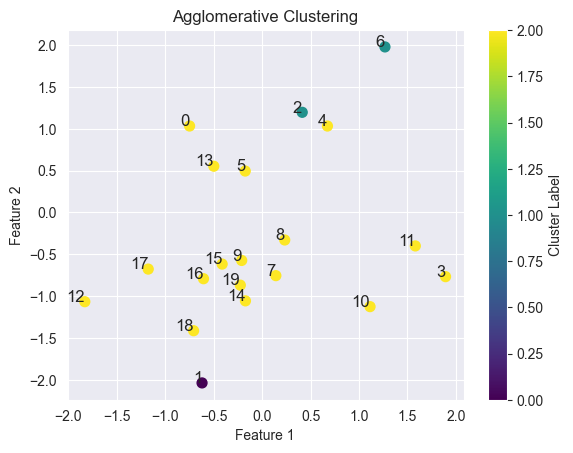

level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
-337.6366129889576
-353.76102727344073
528 36
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
-352.53923668429906
10.570575285285285


np.float64(-441.51760319829816)

In [7]:
#X = np.random.uniform(-1, 1, size=(4, 2))
#X, y = make_blobs(n_samples=20, centers=19, cluster_std=1,random_state=42)
n=20
p=2
sigma=1
mu = np.zeros(p)  
X = generate_null_data(n,p,mu,sigma)
# Fit agglomerative clustering
model = AgglomerativeClustering(X, tau=1, n_clusters=3,linkage="single")
model.fit()
# Create an array to hold the assigned cluster labels
cluster_labels = np.zeros(X.shape[0], dtype=int)

# Assign cluster labels from the final cluster nodes
for idx, node in enumerate(model.cluster_nodes):
    for point_index in node.points:
        cluster_labels[point_index] = idx

    # Visualize the clusters
plt.scatter(X[:, 0], X[:, 1], s=50, c=cluster_labels, cmap='viridis', label='Data Points')
plt.title('Agglomerative Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Cluster Label')
for i in range(len(X)):
    plt.annotate(str(i), (X[i, 0], X[i, 1]), fontsize=12, ha='right')

plt.show()
winning_nodes = list(model.existing_clusters_log.keys())
key = winning_nodes[-1]
node = key[0].parent
pvalue, obs,sel_prob, sel_corrected, grid_upper,grid_lower = model.merge_inference(node, grid_width=20,ncoarse=20,ngrid=1000)
#pvalue, obs,sel_prob = model.merge_inference(node, grid_width=15,ncoarse=20,ngrid=1000)
np.min(sel_prob)

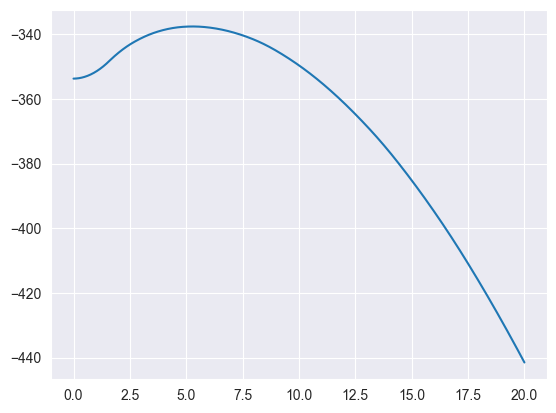

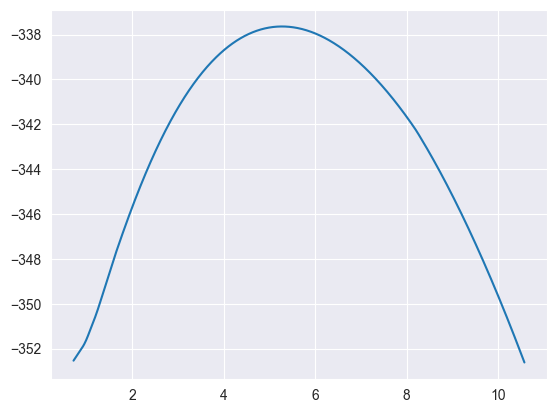

In [8]:
ref_norm_cor = (sel_corrected)
#x = np.linspace(0, 1.5*np.abs(obs_tar), 10000)
x = np.linspace(grid_lower, grid_upper,num=1000)
ref_norm = sel_prob
#x = np.linspace(0, 1.5*np.abs(obs_tar), 10000)
y = np.linspace(0.00001,20,num=1000)
plt.plot(y, ref_norm)
plt.show()
plt.plot(x, ref_norm_cor)
plt.show()

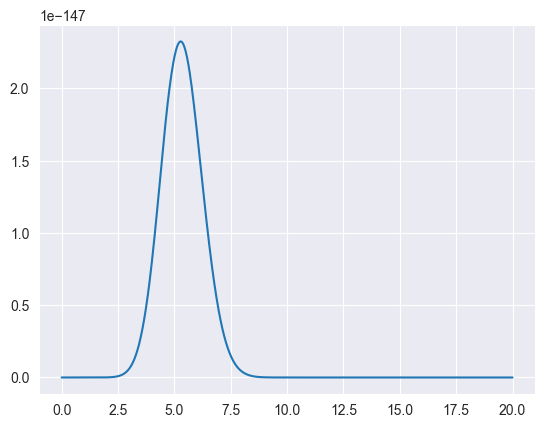

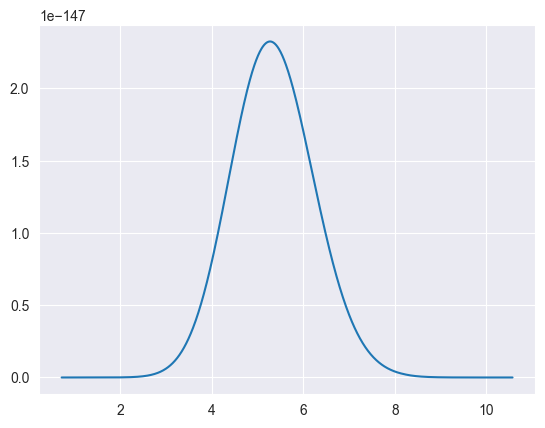

In [9]:
ref_norm_cor = np.exp(sel_corrected)
#x = np.linspace(0, 1.5*np.abs(obs_tar), 10000)
x = np.linspace(grid_lower, grid_upper,num=1000)
ref_norm = np.exp(sel_prob)
#x = np.linspace(0, 1.5*np.abs(obs_tar), 10000)
y = np.linspace(0.00001, 20,num=1000)
plt.plot(y, ref_norm)
plt.show()
plt.plot(x, ref_norm_cor)
plt.show()

In [11]:
n = X.shape[0]
def compute_nu(node):
    # return the projection direction from the given node
    G_1= np.array(node.left.points)
    G_2 = np.array(node.right.points)
    n_G1 = len(G_1)
    n_G2 = len(G_2)

    nu = np.zeros(n)

    nu[G_1] += 1/n_G1
    nu[G_2] -= 1/n_G2
    return nu

def compute_dirT(w):
    # return dir(w)^T
    norm = np.linalg.norm(w)
    dir_w = (w / norm) if norm != 0 else np.zeros_like(w)
    return dir_w.T
nu = compute_nu(node)

nuisance = (np.eye(n) - np.outer(nu,nu)/np.linalg.norm(nu)**2) @ X
contrast = X.T@nu
dir = compute_dirT(X.T@nu)
ngrid=100
grid_width=15
stat_grid = np.linspace(0.0001, grid_width, num=ngrid)

In [12]:
norm_nu = nu/np.linalg.norm(nu)
print(np.isclose(np.linalg.norm(X.T@norm_nu), np.linalg.norm(X.T@nu)/np.linalg.norm(nu)))

True


In [ ]:
model._approx_log_reference(node, stat_grid, nuisance,dir, sd=1)

level:  1
-2.8402530748479013
-2.8402530748479013
359 0
level:  1
-2.8402530748479013
7.1871935935935936
Original selection probability:  -256.0458817809865
Selection probability:  -32.69077901897657
level:  1
-3.654603681696769
-3.654603681696769
326 0
level:  1
-3.654603681696769
6.526533263263263
Original selection probability:  -286.69904383449534
Selection probability:  -33.4831924320387
level:  1
-2.8218546909688254
-2.8218546909688254
388 0
level:  1
-2.8218546909688254
7.767773883883884
Original selection probability:  -241.86897477560836
Selection probability:  -32.76314694702637
level:  1
-3.3693958500229804
-3.3693958500229804
347 0
level:  1
-3.3693958500229804
6.9469534734734735
Original selection probability:  -270.7996052743073
Selection probability:  -33.35750664522412
level:  1
-3.4769198743588965
-3.4769198743588965
348 0
level:  1
-3.4769198743588965
6.966973483483484
Original selection probability:  -269.8958887543729
Selection probability:  -33.33543785136929
level

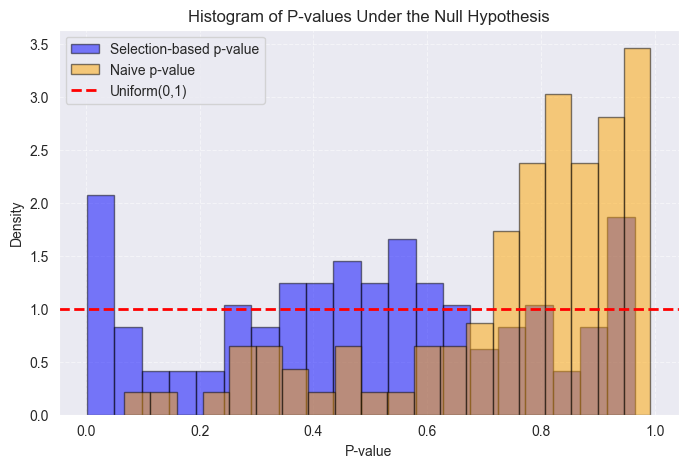

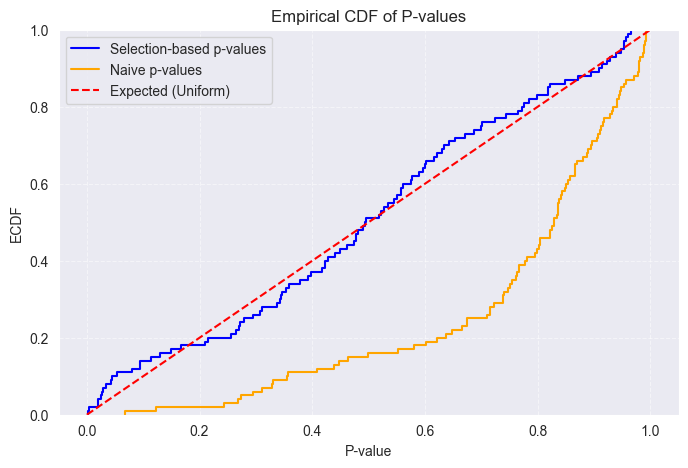

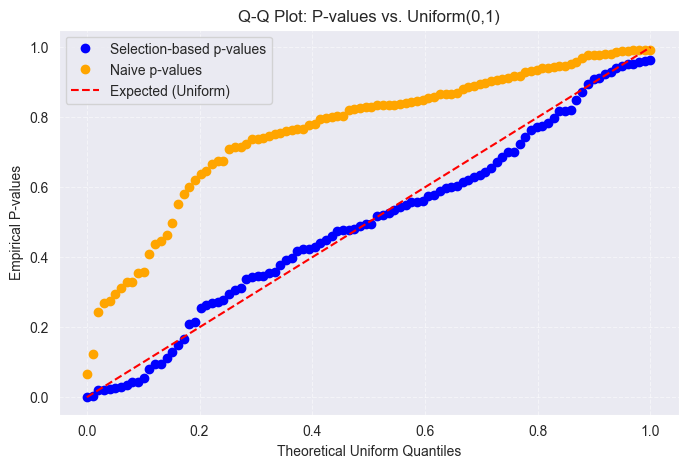

In [16]:
check_p_value_uniformity(5,2,1,4,1,-1,100)

level:  1
Original selection probability:  -367.4396315616821
Selection probability:  0.0
level:  1
Original selection probability:  -370.3610499908183
Selection probability:  0.0
level:  1
Original selection probability:  -364.54824327057264
Selection probability:  0.0
level:  1
Original selection probability:  -370.9516176537607
Selection probability:  0.0
level:  1
Original selection probability:  -371.1052939443532
Selection probability:  0.0
level:  1
Original selection probability:  -368.9899019538766
Selection probability:  0.0
level:  1
Original selection probability:  -376.67250535015955
Selection probability:  0.0
level:  1
Original selection probability:  -368.35163159826607
Selection probability:  0.0
level:  1
Original selection probability:  -371.6990751353484
Selection probability:  0.0
level:  1
Original selection probability:  -370.67254632832896
Selection probability:  0.0
level:  1
Original selection probability:  -372.67939192314475
Selection probability:  0.0
level

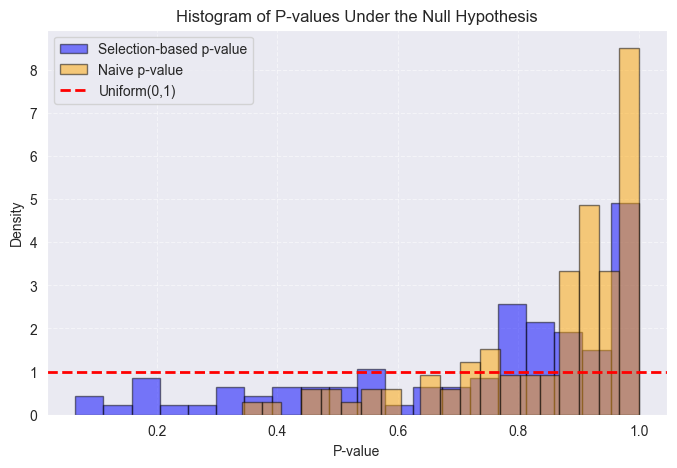

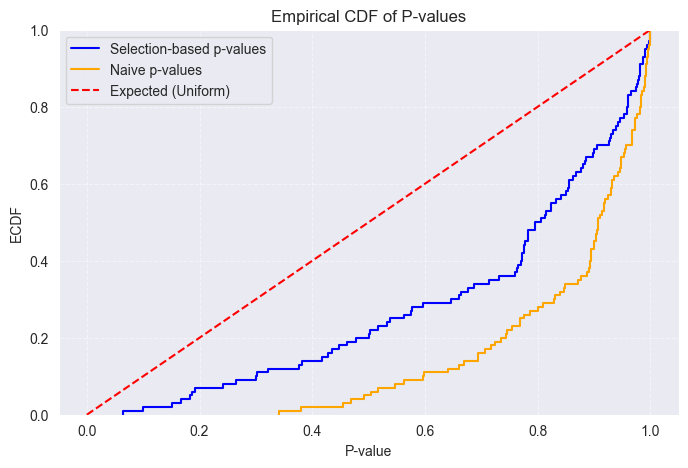

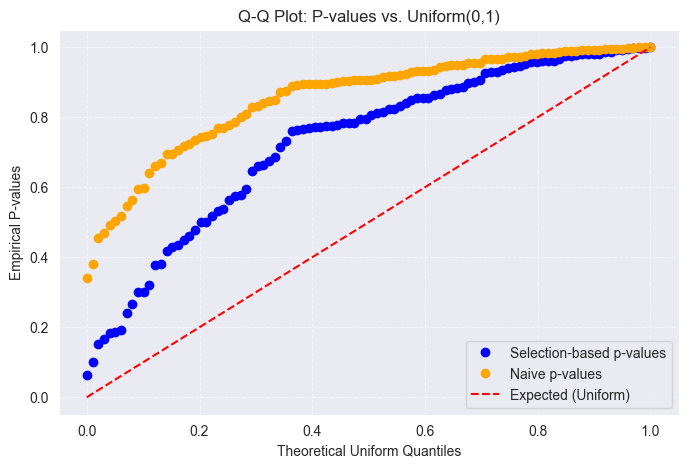

In [3]:
check_p_value_uniformity(20,2,1,19,1,-1,100)

level:  1
-16.29422247556175
-16.29422247556175
435 0
level:  1
-16.29422247556175
8.708714354354354
Original selection probability:  -133.29571176399753
Selection probability:  -46.19938912595411
level:  1
-16.574563226287893
-16.574563226287893
429 0
level:  1
-16.574563226287893
8.588594294294294
Original selection probability:  -135.17101874171908
Selection probability:  -46.52923121734581
level:  1
-16.273759391314023
-16.273759391314023
436 0
level:  1
-16.273759391314023
8.728734364364364
Original selection probability:  -133.17100128347653
Selection probability:  -46.243623522208075
level:  1
-16.40677731867047
-16.40677731867047
430 0
level:  1
-16.40677731867047
8.608614304304304
Original selection probability:  -134.52561343429147
Selection probability:  -46.35950273753777
level:  1
-16.54672888649108
-16.54672888649108
432 0
level:  1
-16.54672888649108
8.648654324324324
Original selection probability:  -134.50824402878538
Selection probability:  -46.48814113787084
level:  

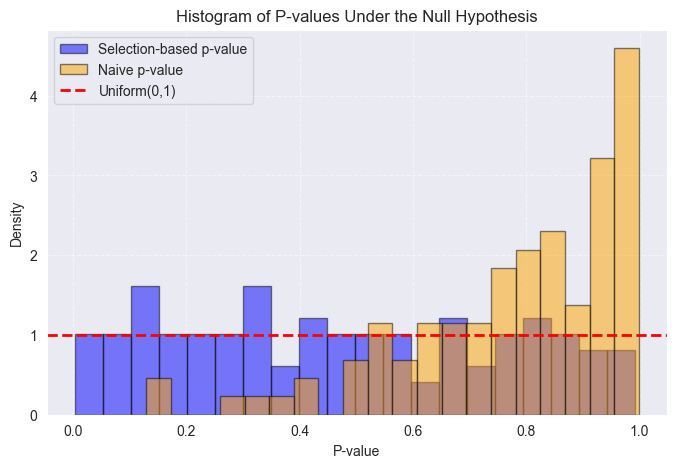

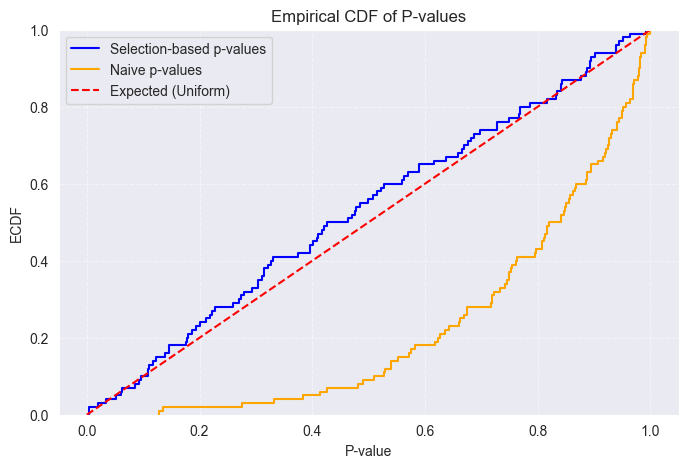

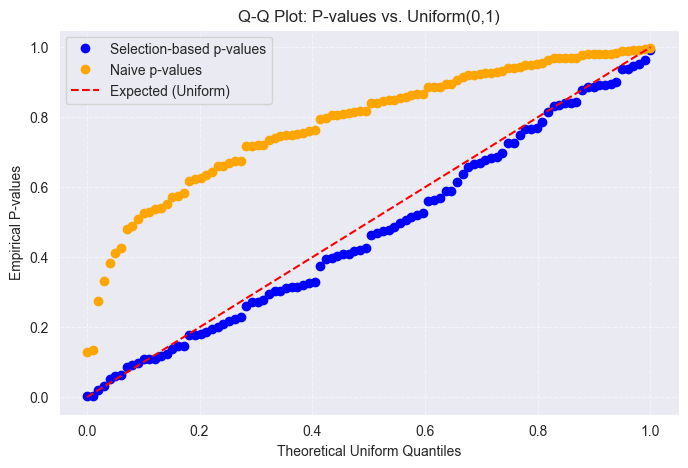

In [3]:
check_p_value_uniformity(20,2,1,19,2,-1,100)

level:  1
Original selection probability:  -131.8611527657415
Selection probability:  0.0
level:  1
Original selection probability:  -133.6259537316093
Selection probability:  0.0
level:  1
Original selection probability:  -132.6419466746645
Selection probability:  0.0
level:  1
Original selection probability:  -133.48663875165198
Selection probability:  0.0
level:  1
Original selection probability:  -133.61091057285284
Selection probability:  0.0
level:  1
Original selection probability:  -136.39953777156495
Selection probability:  0.0
level:  1
Original selection probability:  -133.61430917162158
Selection probability:  0.0
level:  1
Original selection probability:  -132.91768887138358
Selection probability:  0.0
level:  1
Original selection probability:  -134.2040501793707
Selection probability:  0.0
level:  1
Original selection probability:  -134.76961154149058
Selection probability:  0.0
level:  1
Original selection probability:  -133.542039323087
Selection probability:  0.0
level

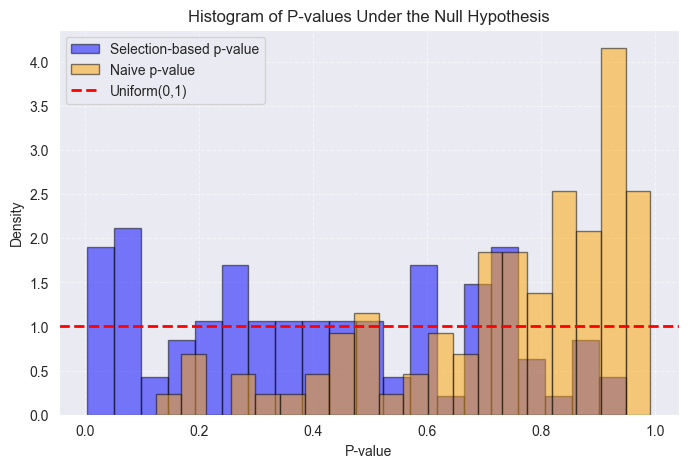

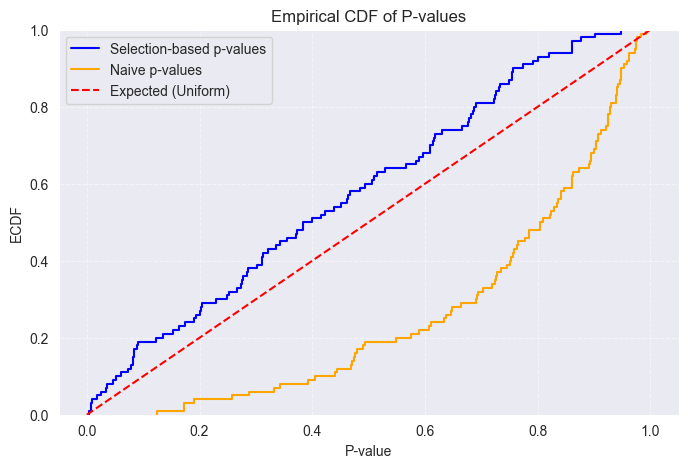

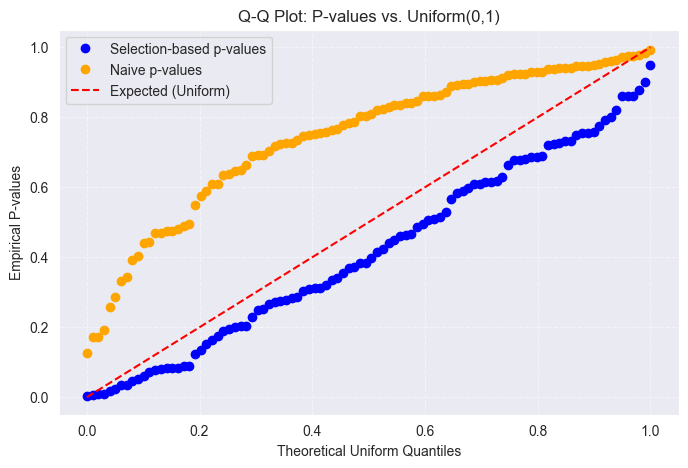

In [3]:
check_p_value_uniformity(20,2,1,19,2,-1,100)

level:  27
level:  26
level:  25
level:  24
level:  23
level:  22
level:  21
level:  20
level:  19
level:  18
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
-251.48846295372002
level:  27
level:  26
level:  25
level:  24
level:  23
level:  22
level:  21
level:  20
level:  19
level:  18
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
-253.61120601944606
level:  27
level:  26
level:  25
level:  24
level:  23
level:  22
level:  21
level:  20
level:  19
level:  18
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
-242.8264484183084
level:  27
level:  26
level:  25
level:  24
level:  23
level:  22
level:  21


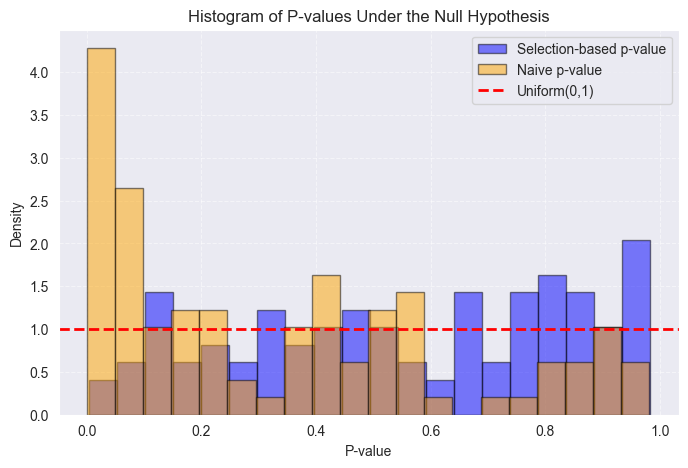

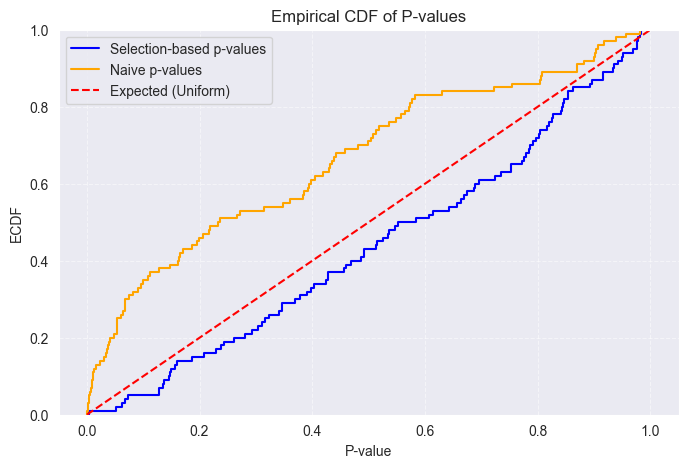

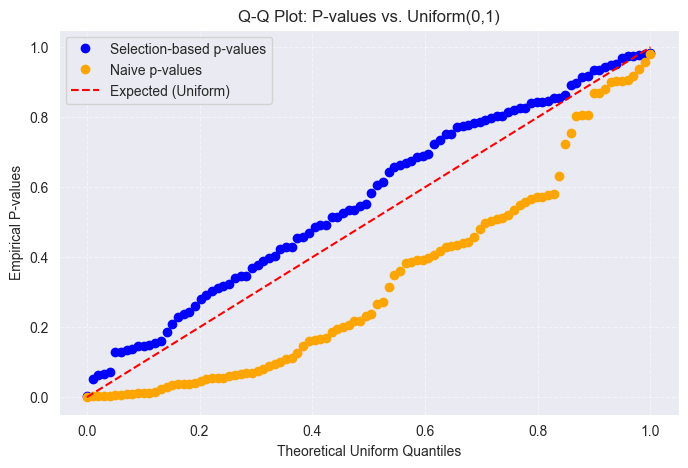

In [3]:
check_p_value_uniformity(30,2,1,3,np.log(20),-1,100)

level:  1
-35.5229219385917
level:  1
-35.344600277085334
level:  1
-35.71303881548485
level:  1
-35.0088997642514
level:  1
-34.19336690522883
level:  1
-34.736499990126184
level:  1
-34.37065224340934
level:  1
-35.369961286741365
level:  1
-34.73780177882011
level:  1
-34.65495568580806
level:  1
-35.5708792800076
level:  1
-35.12057264355608
level:  1
-35.48812609320247
level:  1
-35.21035279098567
level:  1
-35.2602722354736
level:  1
-35.29258294660767
level:  1
-35.03448958966535
level:  1
-35.19224253300523
level:  1
-35.019564366338614
level:  1
-35.173771166138856
level:  1
-35.14188318594466
level:  1
-35.32075423180133
level:  1
-36.80918241079619
level:  1
-34.01005237408559
level:  1
-34.674431528258154
level:  1
-35.88553387178743
level:  1
-34.499939392962276
level:  1
-34.772190471143496
level:  1
-35.516720190470714
level:  1
-35.88000962345382
level:  1
-34.99989078571481
level:  1
-34.75147078414026
level:  1
-34.710572525319776
level:  1
-35.9766241369436
level:  1

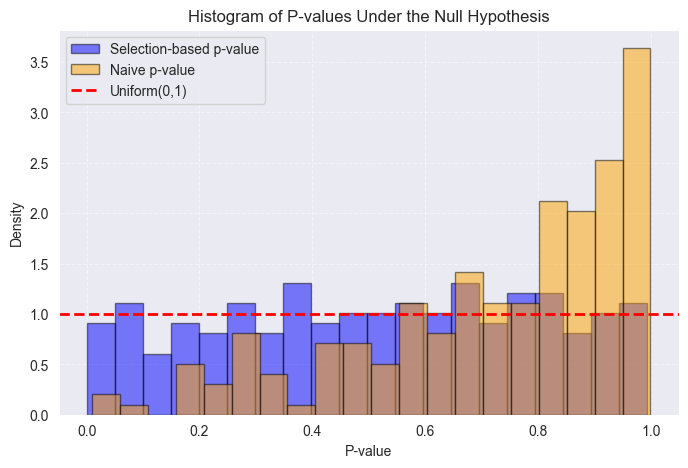

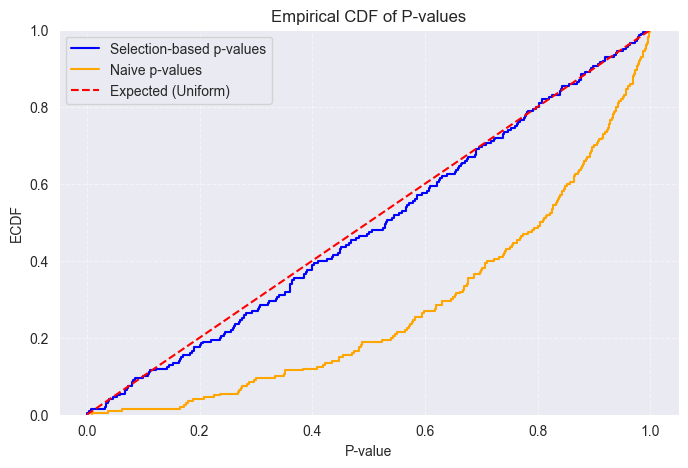

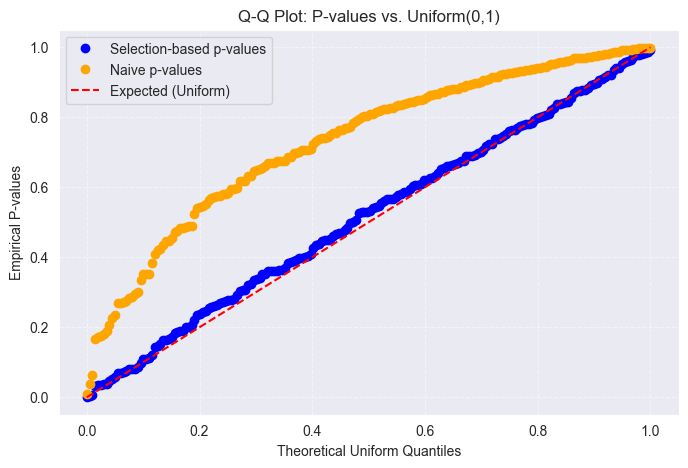

In [3]:
check_p_value_uniformity(20,15,1,19,np.log(20),-1,200)

level:  1
-5.953430953546688
level:  1
-5.918415251688836
level:  1
-5.807449591686842
level:  1
-5.915730866135025
level:  1
-5.847341758964905
level:  1
-5.920512551472791
level:  1
-5.834492977672216
level:  1
-5.777682327491377
level:  1
-5.859740702449299
level:  1
-5.949834556770279
level:  1
-5.799577800479197
level:  1
-5.957126459625757
level:  1
-5.8248720380348376
level:  1
-5.839540166633486
level:  1
-5.7984799409476935
level:  1
-5.824262633699647
level:  1
-5.889510179234982
level:  1
-5.860394555367364
level:  1
-5.8901299547896215
level:  1
-5.810747736295406
level:  1
-5.812850404447378
level:  1
-5.764632948076432
level:  1
-5.901081792221447
level:  1
-5.890703278427624
level:  1
-5.853310299878849
level:  1
-5.786727095190874
level:  1
-5.947115501918756
level:  1
-5.908951522122971
level:  1
-5.8222673266449565
level:  1
-5.875967199016218
level:  1
-5.867689410943708
level:  1
-5.919583560008602
level:  1
-5.877415323649341
level:  1
-5.893952473753313
level:  1


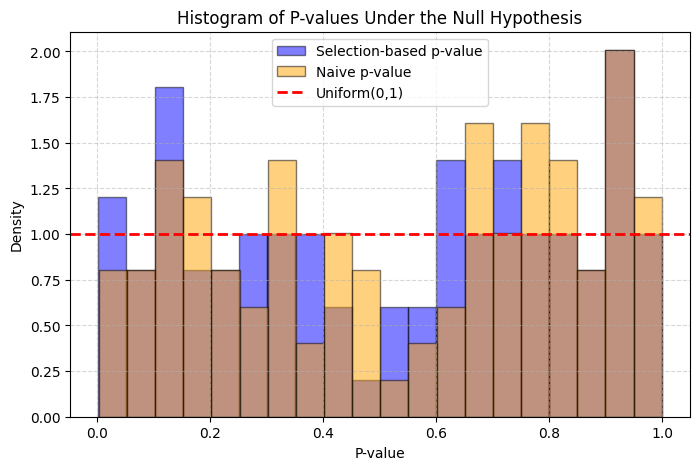

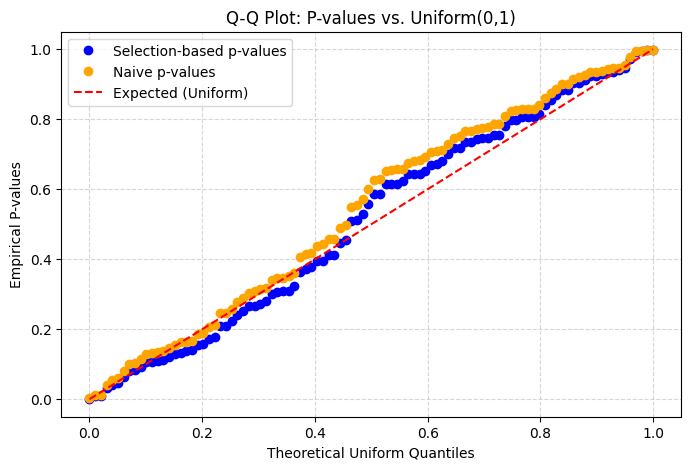

In [87]:
check_p_value_uniformity(20,2,1,19,10,-1,100)

level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
le

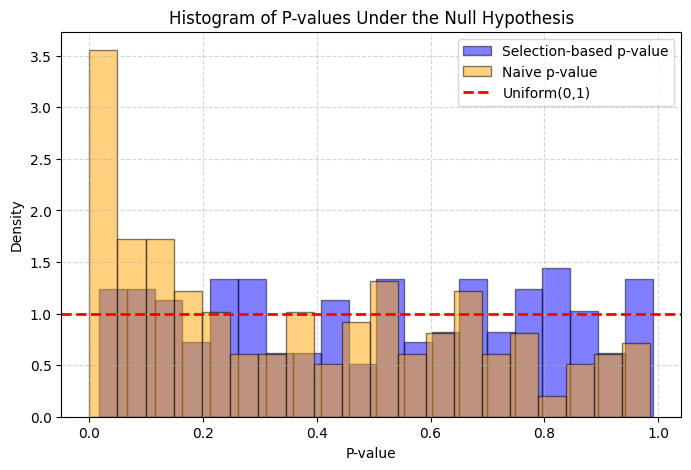

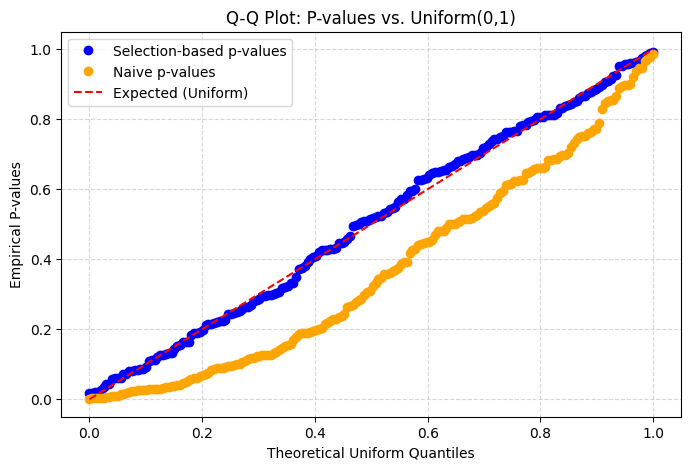

In [31]:
check_p_value_uniformity(20,2,1,3,np.log(20),-1,200)

level:  1
-29.6981013744938
level:  1
-30.30551050885648
level:  1
-30.890393390463764
level:  1
-30.576846549109057
level:  1
-31.461458125334282
level:  1
-30.585953655830323
level:  1
-30.05431092645543
level:  1
-30.08598603872609
level:  1
-30.20889959246029
level:  1
-29.981392245162233
level:  1
-29.3694896518131
level:  1
-30.266857887556206
level:  1
-30.394157241620167
level:  1
-30.869962096853413
level:  1
-30.949051884283055
level:  1
-30.74066576462951
level:  1
-30.591530669894983
level:  1
-31.047628993439737
level:  1
-30.123548300888896
level:  1
-30.080643760290176
level:  1
-29.584204220995595
level:  1
-30.232139399423012
level:  1
-30.657799810301135
level:  1
-30.910552590745944
level:  1
-30.31540656095717
level:  1
-30.45702668606181
level:  1
-30.193149015401588
level:  1
-30.042565823159077
level:  1
-30.223616147492706
level:  1
-30.34048953736898
level:  1
-30.80727943244681
level:  1
-30.67184337089264
level:  1
-30.66019339300873
level:  1
-30.23019732144

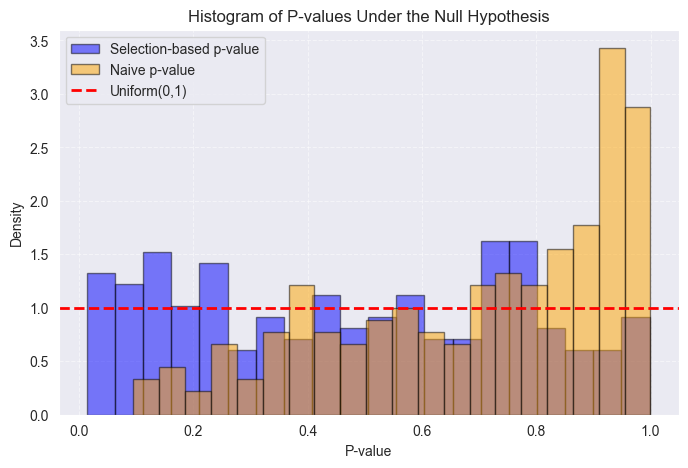

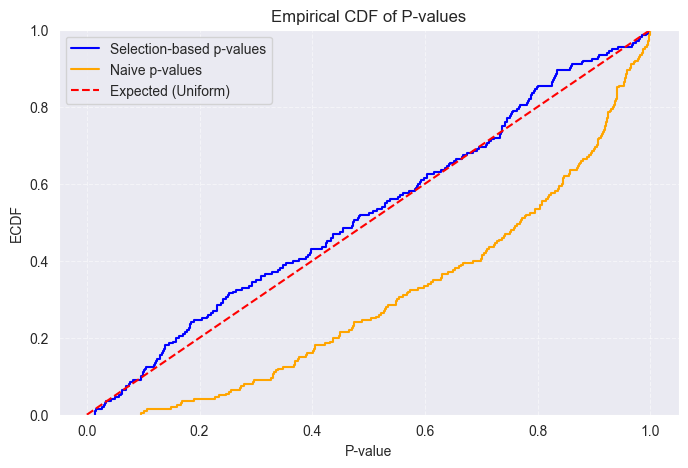

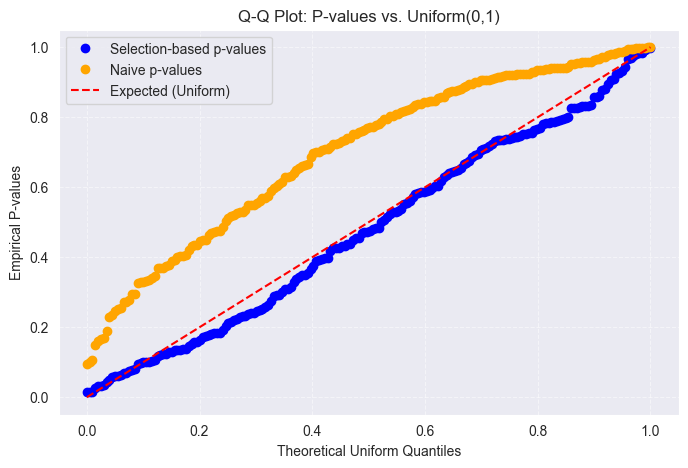

In [30]:
check_p_value_uniformity(20,30,1,19,np.log(20),-1,200)

In [ ]:
np.log(20)

level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  7
level:  6


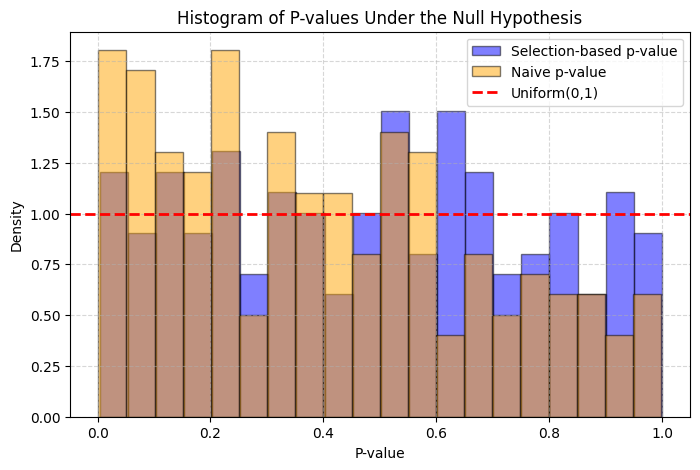

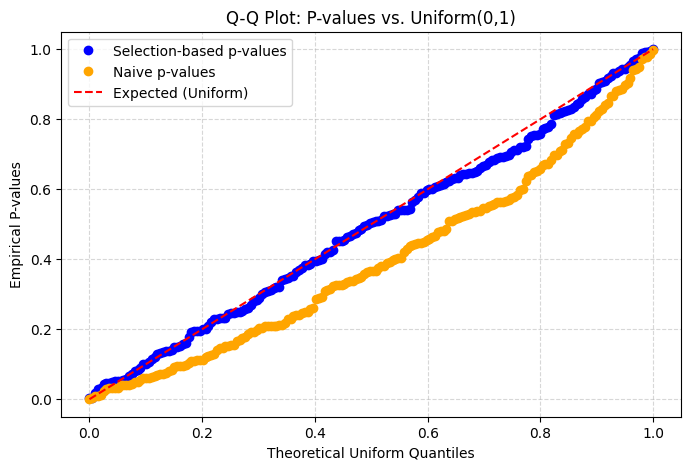

In [35]:
check_p_value_uniformity(10,15,1,3,np.log(10),-1,200)

level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1


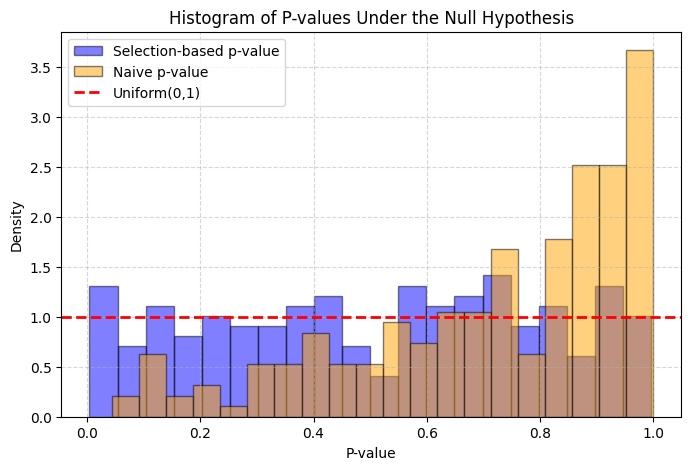

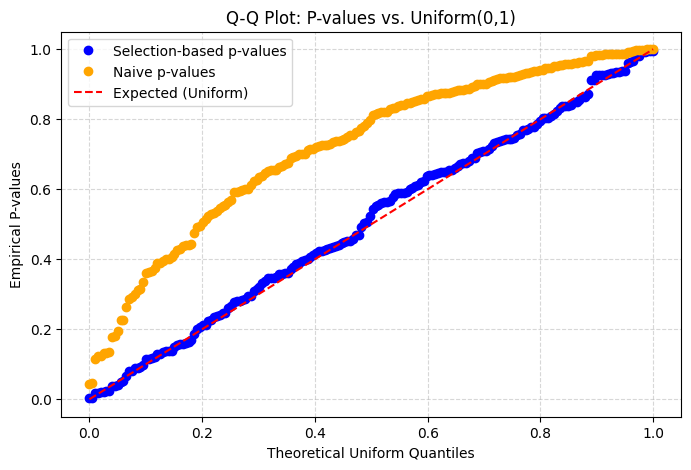

In [37]:
check_p_value_uniformity(20,15,1,19,np.log(20),-1,200)

level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1


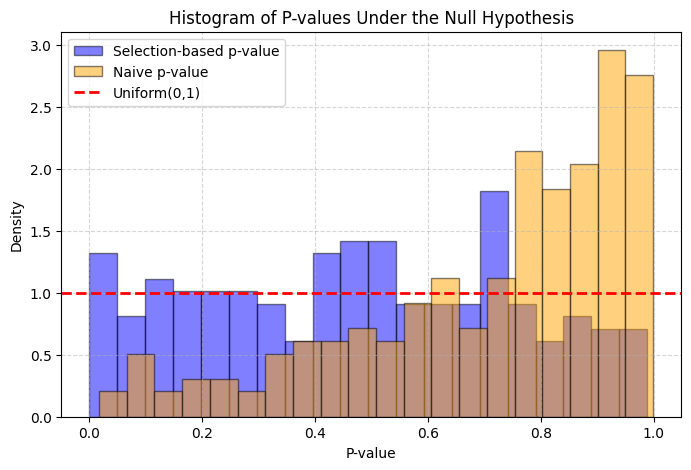

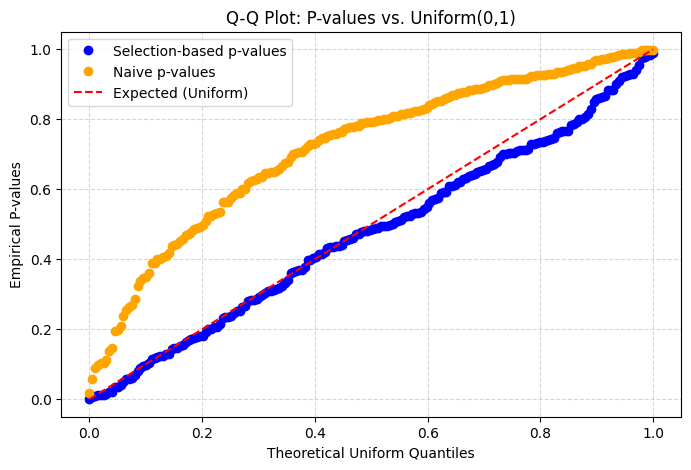

In [26]:
check_p_value_uniformity(30,15,1,29,np.log(30),-1,200)

level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1


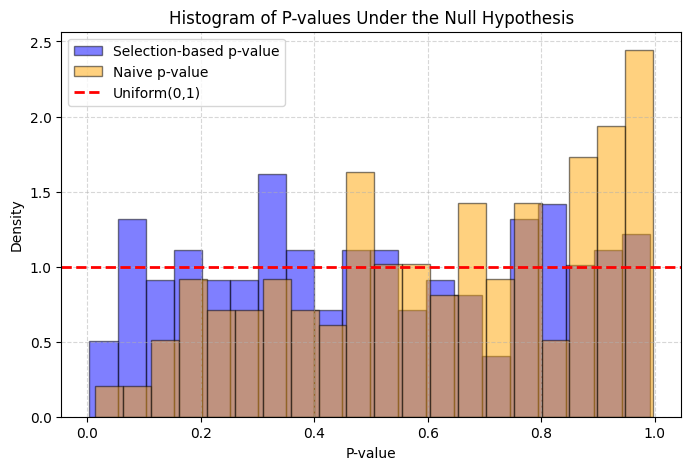

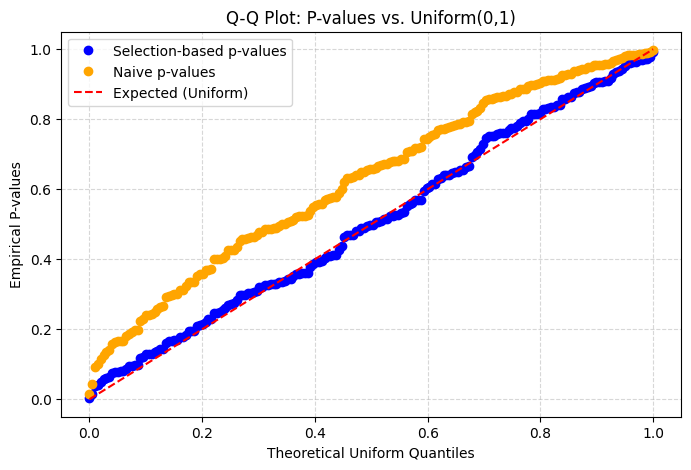

In [28]:
check_p_value_uniformity(30,15,1,29,np.sqrt(30),-1,200)

level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1


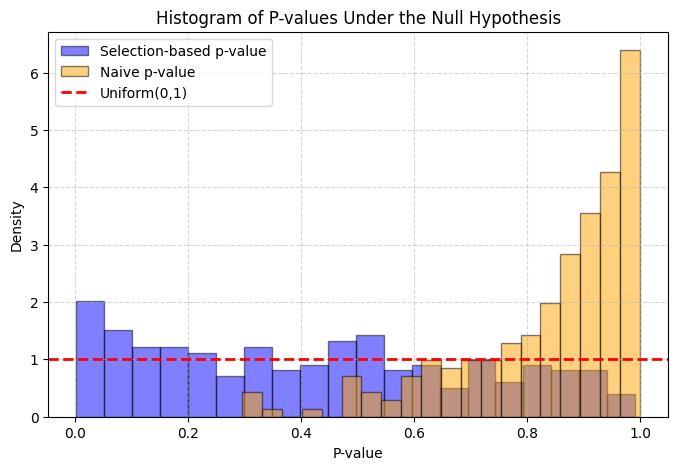

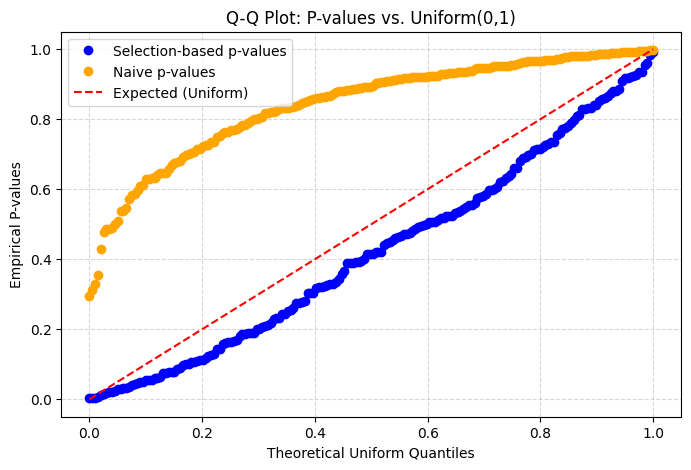

In [51]:
check_p_value_uniformity(10,2,1,9,1,-1,200)

level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1


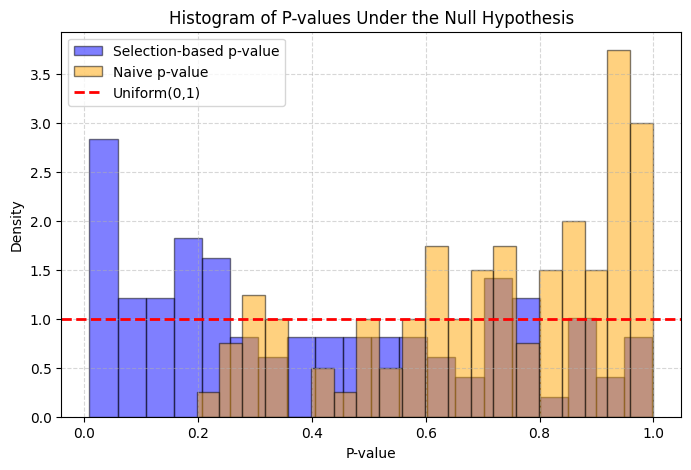

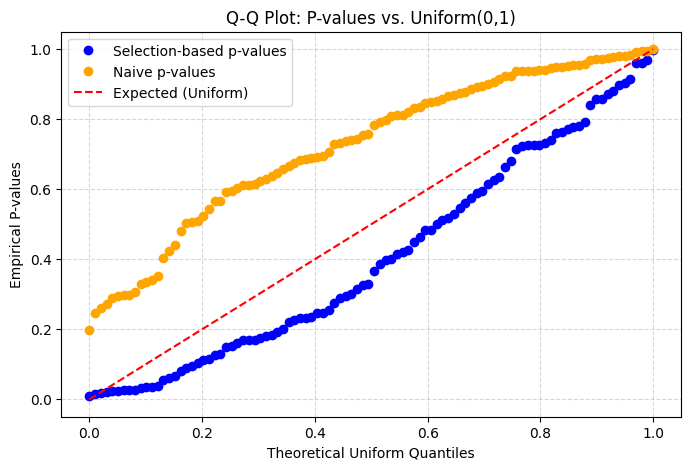

In [48]:
check_p_value_uniformity(20,2,1,19,2,-1,100)

level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1


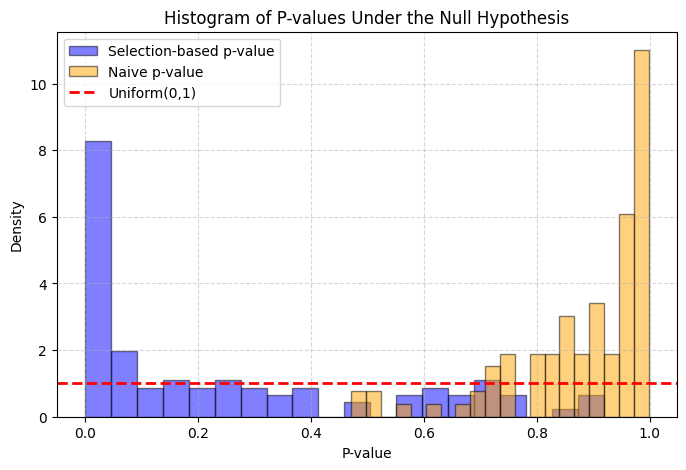

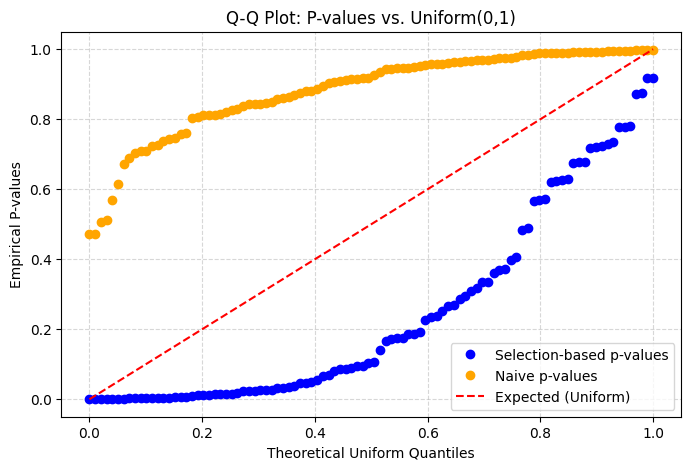

In [50]:
check_p_value_uniformity(30,2,1,29,1,-1,100)

In [ ]:
check_p_value_uniformity(20,2,1,19,5,-1,100)

In [ ]:
check_p_value_uniformity(100,30,1,99,5,-1,50)

In [ ]:
check_p_value_uniformity(20,15,1,10,1*np.sqrt(20),-1,100)

In [ ]:
check_p_value_uniformity(30,15,1,10,1*np.sqrt(30),-1,100)

In [ ]:
check_p_value_uniformity(30,15,1,3,1*np.sqrt(30),-1,200)

In [ ]:
def plot_p_value(stat_grid, cdf, observed_target, p_value):
    observed_cdf_value = np.interp(observed_target, stat_grid, cdf)
    
    plt.figure(figsize=(8, 5))
    
    plt.plot(stat_grid, cdf, label="CDF", color="blue", lw=2)
    plt.axvline(observed_target, color='red', linestyle='dashed', lw=2, label="Observed Target")
    
    plt.fill_between(stat_grid, cdf, 1, where=(stat_grid >= observed_target), color='red', alpha=0.3, label="p-value region")

    plt.text(observed_target, 0.05, f"Observed Target = {observed_target:.3f}", color='red', fontsize=12, rotation=90, verticalalignment='bottom')
    plt.text(stat_grid[-1]*0.85, 0.8, f"p-value = {p_value:.4f}", color='red', fontsize=14, bbox=dict(facecolor='white', edgecolor='red'))

    plt.xlabel(r"$X$ (Test Statistic)")
    plt.ylabel("Cumulative Probability (CDF)")
    plt.title("Visualization of p-value")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
  
    plt.show()

In [ ]:
grid = np.linspace(0.00001, 15, num=1000)

In [ ]:
winning_nodes = list(model.existing_clusters_log.keys())
key = winning_nodes[-1]
node = key[0].parent
pvalue, obs, cdf = model.merge_inference(node)
pvalue

In [ ]:
plot_p_value(grid, cdf, obs, pvalue)

In [ ]:
winning_nodes = list(model.existing_clusters_log.keys())
key = winning_nodes[-1]
node = key[0].parent
pvalue, obs, cdf = model.merge_inference(node)
pvalue

In [ ]:
plot_p_value(grid, cdf, obs, pvalue)

In [ ]:
print("\nExisting Clusters Log:")
for key, value in model.existing_clusters_log.items():
    print(f"Merge: {key} -> Clusters: {value}")

In [ ]:
X, y = make_blobs(n_samples=50, centers=4, cluster_std=1,random_state=42)

# Fit agglomerative clustering
model = AgglomerativeClustering(X, tau=1, n_clusters=3,linkage="single")
model.fit()
# Create an array to hold the assigned cluster labels
cluster_labels = np.zeros(X.shape[0], dtype=int)

# Assign cluster labels from the final cluster nodes
for idx, node in enumerate(model.cluster_nodes):
    for point_index in node.points:
        cluster_labels[point_index] = idx

    # Visualize the clusters
plt.scatter(X[:, 0], X[:, 1], s=50, c=cluster_labels, cmap='viridis', label='Data Points')
plt.title('Agglomerative Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Cluster Label')
for i in range(len(X)):
    plt.annotate(str(i), (X[i, 0], X[i, 1]), fontsize=12, ha='right')

plt.show()

In [ ]:
pvalue

In [ ]:
plot_p_value(grid, cdf, obs, pvalue)

In [ ]:
winning_nodes = list(model.existing_clusters_log.keys())
key = winning_nodes[3]
node = key[0].parent
pvalue, obs, cdf = model.merge_inference(node)
pvalue

In [ ]:
plot_p_value(grid, cdf, obs, pvalue)

In [ ]:
winning_nodes = list(model.existing_clusters_log.keys())
key = winning_nodes[0]
node = key[0].parent

In [ ]:
node

In [ ]:
model.merge_inference(node)

In [ ]:
model.existing_clusters_log.keys()

In [ ]:
model.distance_matrix

In [ ]:
print("Distance Log:")
for key, value in model.distance_log.items():
    print(f"{key}: {value}")

In [ ]:
print("\nExisting Clusters Log:")
for key, value in model.existing_clusters_log.items():
    print(f"Merge: {key} -> Clusters: {value}")

In [ ]:
print("Randomization Log:")
for key, value in model.randomization_log.items():
    print(f"{key}: {value}")


In [ ]:
model.get_all_winning_pairs()

In [ ]:
np.random.normal(0,1,(10,1))

In [ ]:
X_grid = np.array([
    [-3.41284633,  8.94302295],
    [-6.63766492, -8.79338984],
    [-5.46153354,  8.71814827],
    [-5.59752253,  8.4386312],
    [ 4.17646114,  1.50743993]
])


In [ ]:
from scipy.spatial import distance
data_new_node = X_grid[3,:].reshape(1,-1)
data_cluster = X_grid[[0,2],:]
distances = distance.cdist(data_new_node, data_cluster, metric='euclidean')
        

In [ ]:
distances

In [ ]:
from scipy.spatial import distance
data_new_node = X_grid[0,:].reshape(1,-1)
data_cluster = X_grid[2,:].reshape(1,-1)
distances = distance.cdist(data_new_node, data_cluster, metric='euclidean')
distances

In [ ]:
data_new_node = X[3,:].reshape(1,-1)
data_cluster = X[[0,2],:]
distances = distance.cdist(data_new_node, data_cluster, metric='euclidean')
distances

In [ ]:
data_new_node = X[0,:].reshape(1,-1)
data_cluster = X[2,:].reshape(1,-1)
distances = distance.cdist(data_new_node, data_cluster, metric='euclidean')
distances